# Titanic Passenger Class Prediction

## End-to-End Machine Learning Pipeline with External Validation

**Author:** Pontus Björkell

---

## Project Overview

This project develops a complete machine learning pipeline for predicting the passenger class (1st, 2nd, or 3rd class) of Titanic passengers using demographic, ticket, and travel information.

Unlike many introductory Titanic projects, this repository focuses on the complete machine learning workflow rather than model training alone. The project includes:

- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Feature engineering
- Multiple machine learning models
- Hyperparameter tuning
- Cross-validation
- Hold-out evaluation
- Independent external validation
- Automated testing
- Production-ready prediction pipeline

The final model is evaluated not only on an internal hold-out test set but also on an entirely independent external Titanic dataset, providing a more realistic assessment of model generalization.

# 1. Problem Statement

Passenger class on the RMS Titanic was closely associated with wealth, accommodation quality, and access to survival resources.

The objective of this project is to predict a passenger's class using information such as:

- Age
- Sex
- Fare
- Family relationships
- Cabin information
- Embarkation port
- Ticket characteristics

The prediction task is formulated as a multiclass classification problem with three target classes:

- First Class
- Second Class
- Third Class

Rather than maximizing leaderboard performance, the project emphasizes reproducibility, robustness, and real-world machine learning practices.

In [1]:
# ==========================================================
# Imports and robust project-path detection
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ----------------------------------------------------------
# Display settings
# ----------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

plt.style.use("ggplot")


# ----------------------------------------------------------
# Find the project root
# ----------------------------------------------------------

def find_project_root(start_path=None):
    """
    Locate the project root whether the notebook is started
    from the repository root or from the notebooks directory.
    """

    start_path = Path(start_path or Path.cwd()).resolve()

    required_markers = [
        Path("data"),
        Path("src"),
    ]

    candidates = [
        start_path,
        *start_path.parents,
    ]

    for candidate in candidates:
        if all((candidate / marker).exists() for marker in required_markers):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root.\n\n"
        f"Current working directory:\n{start_path}\n\n"
        "Expected to find a parent directory containing both "
        "'data' and 'src' folders."
    )


PROJECT_ROOT = find_project_root()

print("=" * 80)
print("Project Path Configuration")
print("=" * 80)
print(f"Current working directory: {Path.cwd()}")
print(f"Detected project root:     {PROJECT_ROOT}")


# ----------------------------------------------------------
# Locate the Titanic training dataset
# ----------------------------------------------------------

data_candidates = [
    PROJECT_ROOT / "data" / "processed" / "train_processed.csv",
    PROJECT_ROOT / "data" / "raw" / "train.csv",
    PROJECT_ROOT / "data" / "raw" / "titanic.csv",
]

DATA_PATH = next(
    (path for path in data_candidates if path.exists()),
    None,
)

if DATA_PATH is None:
    checked_paths = "\n".join(
        f"  - {path}"
        for path in data_candidates
    )

    raise FileNotFoundError(
        "The Titanic training dataset could not be found.\n\n"
        "Checked the following locations:\n"
        f"{checked_paths}\n\n"
        "Confirm that the CSV is stored inside the project's "
        "data/raw or data/processed directory."
    )


# ----------------------------------------------------------
# Load the dataset
# ----------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("\n" + "=" * 80)
print("Dataset Loaded Successfully")
print("=" * 80)
print(f"File:    {DATA_PATH}")
print(f"Shape:   {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Columns: {list(df.columns)}")

display(df.head())

Project Path Configuration
Current working directory: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/notebooks
Detected project root:     /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction

Dataset Loaded Successfully
File:    /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/data/raw/train.csv
Shape:   891 rows × 12 columns
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# ==========================================================
# Centralized project paths
# ==========================================================

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"

RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXTERNAL_DATA_DIR = DATA_DIR / "external"

METRICS_DIR = ARTIFACTS_DIR / "metrics"
MODELS_DIR = ARTIFACTS_DIR / "models"
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"

EXTERNAL_PREDICTIONS_DIR = (
    PREDICTIONS_DIR / "external_nonoverlap"
)

FIGURES_DIR = REPORTS_DIR / "figures"

print("=" * 80)
print("Project Directories")
print("=" * 80)
print(f"Project root:          {PROJECT_ROOT}")
print(f"Data directory:        {DATA_DIR}")
print(f"Metrics directory:     {METRICS_DIR}")
print(f"Models directory:      {MODELS_DIR}")
print(f"Predictions directory: {EXTERNAL_PREDICTIONS_DIR}")
print(f"Figures directory:     {FIGURES_DIR}")

Project Directories
Project root:          /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction
Data directory:        /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/data
Metrics directory:     /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/metrics
Models directory:      /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/models
Predictions directory: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/predictions/external_nonoverlap
Figures directory:     /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/reports/figures


In [3]:
# ==========================================================
# Global notebook styling
# ==========================================================

from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# ----------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


# ----------------------------------------------------------
# Pandas display settings
# ----------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


# ----------------------------------------------------------
# Plotting theme
# ----------------------------------------------------------

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.05,
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.labelweight": "normal",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "legend.title_fontsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "grid.alpha": 0.25,
        "figure.autolayout": False,
    }
)


# ----------------------------------------------------------
# Consistent project palette
# ----------------------------------------------------------

CLASS_PALETTE = {
    1: "#355C7D",
    2: "#6C9BCF",
    3: "#C06C84",
}

CLASS_ORDER = [1, 2, 3]

BINARY_PALETTE = {
    0: "#B8C0CC",
    1: "#4C78A8",
}


# ----------------------------------------------------------
# Reusable plotting helpers
# ----------------------------------------------------------

def finish_plot(
    title,
    xlabel=None,
    ylabel=None,
    legend_title=None,
    rotate_x=0,
):
    """
    Apply consistent formatting to the current Matplotlib axes.
    """

    ax = plt.gca()

    ax.set_title(
        title,
        pad=16,
        loc="left",
    )

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if rotate_x:
        plt.setp(
            ax.get_xticklabels(),
            rotation=rotate_x,
            ha="right",
        )

    legend = ax.get_legend()

    if legend is not None and legend_title is not None:
        legend.set_title(legend_title)

    plt.tight_layout()
    plt.show()


def add_bar_labels(
    ax=None,
    decimals=0,
    suffix="",
):
    """
    Add formatted value labels to vertical or horizontal bars.
    """

    if ax is None:
        ax = plt.gca()

    for container in ax.containers:

        labels = []

        for bar in container:

            value = (
                bar.get_height()
                if bar.get_height() != 0
                else bar.get_width()
            )

            if decimals == 0:
                label = f"{value:,.0f}{suffix}"
            else:
                label = f"{value:,.{decimals}f}{suffix}"

            labels.append(label)

        try:
            ax.bar_label(
                container,
                labels=labels,
                padding=3,
                fontsize=9,
            )
        except ValueError:
            pass


def clean_table(
    dataframe,
    decimals=3,
    percent_columns=None,
    integer_columns=None,
):
    """
    Return a presentation-ready copy of a dataframe.
    """

    table = dataframe.copy()

    percent_columns = percent_columns or []
    integer_columns = integer_columns or []

    numeric_columns = table.select_dtypes(
        include="number"
    ).columns

    for column in numeric_columns:

        if column in percent_columns:

            table[column] = table[column].map(
                lambda value: (
                    f"{value:.1%}"
                    if pd.notna(value)
                    else ""
                )
            )

        elif column in integer_columns:

            table[column] = table[column].map(
                lambda value: (
                    f"{value:,.0f}"
                    if pd.notna(value)
                    else ""
                )
            )

        else:

            table[column] = table[column].map(
                lambda value: (
                    f"{value:,.{decimals}f}"
                    if pd.notna(value)
                    else ""
                )
            )

    return table


def display_section_table(
    dataframe,
    caption=None,
    decimals=3,
    percent_columns=None,
    integer_columns=None,
):
    """
    Display a consistently formatted table in the notebook.
    """

    formatted = clean_table(
        dataframe=dataframe,
        decimals=decimals,
        percent_columns=percent_columns,
        integer_columns=integer_columns,
    )

    styled = (
        formatted.style
        .hide(axis="index")
        .set_properties(
            **{
                "text-align": "left",
                "padding": "7px",
            }
        )
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("font-weight", "bold"),
                        ("text-align", "left"),
                        ("border-bottom", "2px solid #999"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("border-bottom", "1px solid #ddd"),
                    ],
                },
            ]
        )
    )

    if caption:
        styled = styled.set_caption(caption)

    display(styled)


print("Notebook styling successfully configured.")

Notebook styling successfully configured.


## Notebook Presentation Standards

To improve readability and visual consistency, the notebook uses a shared presentation system across all analyses.

The formatting standards include:

- Consistent figure dimensions
- Left-aligned descriptive titles
- Clear axis labels
- Stable class ordering
- A shared passenger-class color palette
- Direct labels on bar charts where useful
- Rounded and consistently formatted tables
- Reduced visual clutter
- High-resolution exported figures

These choices improve presentation without changing the underlying analysis or model results.

# 2. Dataset Overview

The processed training dataset contains cleaned passenger records used for model development.

Before training any machine learning model it is important to understand:

- dataset dimensions
- variable types
- missing values
- class balance
- descriptive statistics

These analyses provide an overview of the data quality and guide later preprocessing decisions.

In [4]:
# ==========================================================
# Dataset overview
# ==========================================================

print("=" * 80)
print("Dataset Information")
print("=" * 80)

display(df.info())

print()

print("=" * 80)
print("Missing Values")
print("=" * 80)

missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

display(missing.to_frame("Missing"))

print()

print("=" * 80)
print("Descriptive Statistics")
print("=" * 80)

display(df.describe(include="all").T)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


None


Missing Values


,Missing
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0



Descriptive Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.000,NaN,NaN,NaN,446.000,257.354,1.000,223.500,446.000,668.500,891.000
Survived,891.000,NaN,NaN,NaN,0.384,0.487,0.000,0.000,0.000,1.000,1.000
Pclass,891.000,NaN,NaN,NaN,2.309,0.836,1.000,2.000,3.000,3.000,3.000
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.000,NaN,NaN,NaN,29.699,14.526,0.420,20.125,28.000,38.000,80.000
SibSp,891.000,NaN,NaN,NaN,0.523,1.103,0.000,0.000,0.000,1.000,8.000
Parch,891.000,NaN,NaN,NaN,0.382,0.806,0.000,0.000,0.000,0.000,6.000
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.000,NaN,NaN,NaN,32.204,49.693,0.000,7.910,14.454,31.000,512.329


# 3. Exploratory Data Analysis

Exploratory Data Analysis helps identify the structure, patterns, and potential limitations of the dataset before model development.

This section focuses on:

- Passenger-class balance
- Fare differences between classes
- Age distributions
- Demographic composition
- Embarkation patterns
- Missing-data structure

Because passenger class is closely connected to socioeconomic status, ticket fare and cabin information are expected to contain substantial predictive information.

Passenger Class,Passengers,Percentage
1,216,24.2%
2,184,20.7%
3,491,55.1%


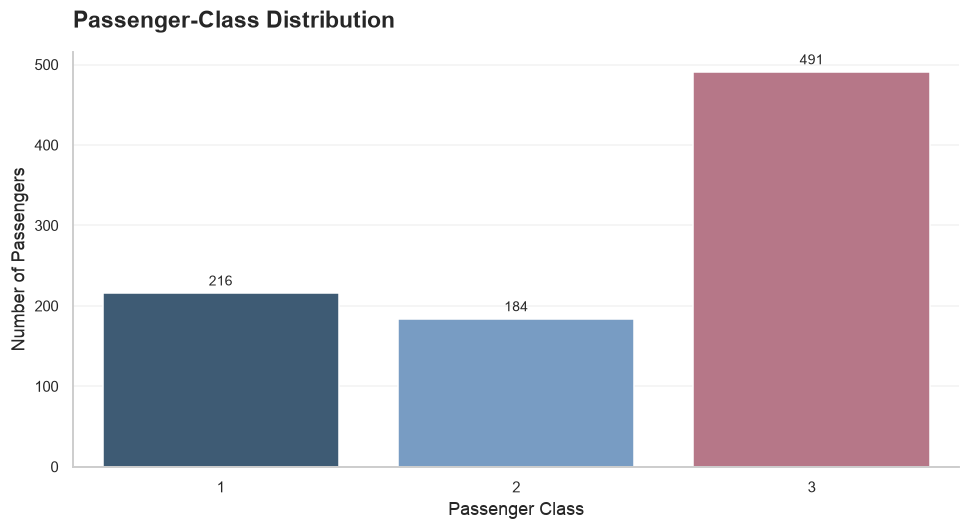

In [5]:
# ==========================================================
# Passenger-class distribution
# ==========================================================

class_counts = (
    df["Pclass"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .rename_axis("Passenger Class")
    .reset_index(name="Passengers")
)

class_counts["Percentage"] = (
    class_counts["Passengers"]
    / class_counts["Passengers"].sum()
)

display_section_table(
    class_counts,
    caption="Passenger-Class Distribution",
    percent_columns=["Percentage"],
    integer_columns=["Passenger Class", "Passengers"],
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=class_counts,
    x="Passenger Class",
    y="Passengers",
    hue="Passenger Class",
    order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    legend=False,
)

add_bar_labels(ax)

finish_plot(
    title="Passenger-Class Distribution",
    xlabel="Passenger Class",
    ylabel="Number of Passengers",
)

## 3.1 Passenger-Class Distribution

The target variable is not evenly distributed.

Third-class passengers form the largest group, while second-class passengers form the smallest. This imbalance is important because a model could achieve deceptively high accuracy by favoring the majority class.

For this reason, later evaluation will consider several metrics:

- Accuracy
- Balanced accuracy
- Macro-averaged precision
- Macro-averaged recall
- Macro F1 score
- Class-specific performance
- Confusion matrices

Macro-averaged metrics give equal importance to all three passenger classes, regardless of their frequency.

Passenger Class,Passengers,Mean,Median,Standard Deviation,Minimum,Maximum
1,216,84.15,60.29,78.38,0.00,512.33
2,184,20.66,14.25,13.42,0.00,73.50
3,491,13.68,8.05,11.78,0.00,69.55


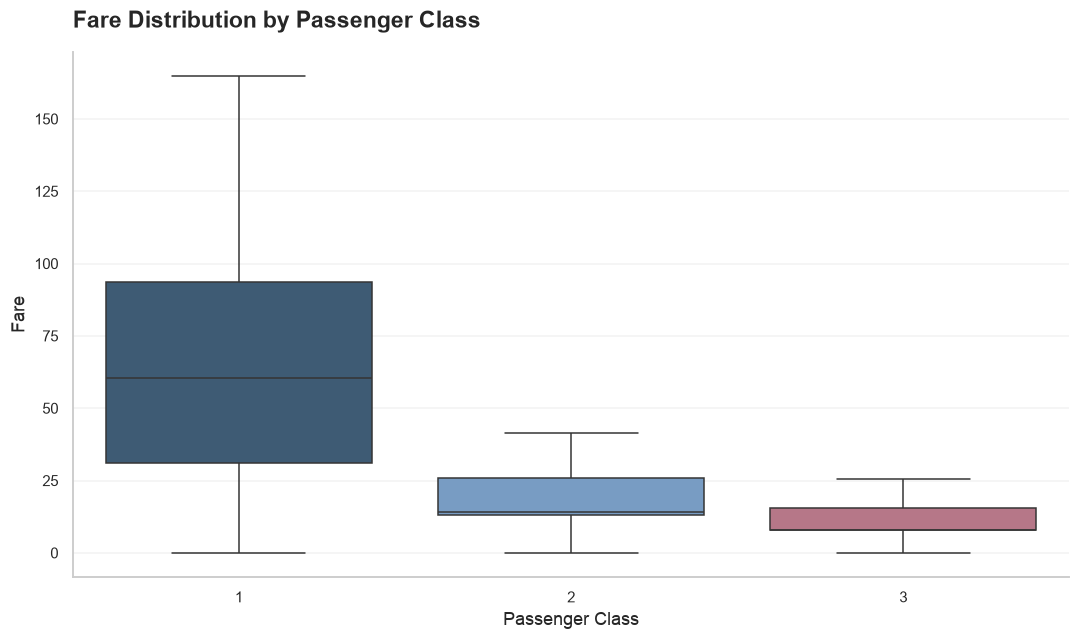

In [6]:
# ==========================================================
# Fare distribution by passenger class
# ==========================================================

fare_summary = (
    df.groupby("Pclass")["Fare"]
    .agg(
        Passengers="count",
        Mean="mean",
        Median="median",
        Standard_Deviation="std",
        Minimum="min",
        Maximum="max",
    )
    .reindex(CLASS_ORDER)
    .reset_index()
    .rename(
        columns={
            "Pclass": "Passenger Class",
            "Standard_Deviation": "Standard Deviation",
        }
    )
)

display_section_table(
    fare_summary,
    caption="Fare Summary by Passenger Class",
    decimals=2,
    integer_columns=["Passenger Class", "Passengers"],
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    order=CLASS_ORDER,
    hue="Pclass",
    palette=CLASS_PALETTE,
    legend=False,
    showfliers=False,
)

finish_plot(
    title="Fare Distribution by Passenger Class",
    xlabel="Passenger Class",
    ylabel="Fare",
)

## 3.2 Fare and Passenger Class

Fare is expected to be one of the strongest predictors of passenger class because the target itself represents the passenger's travel category.

The distributions show a clear socioeconomic gradient:

- First-class passengers generally paid the highest fares.
- Second-class passengers occupied an intermediate range.
- Third-class passengers generally paid the lowest fares.

However, the classes are not perfectly separated. Fare overlap can occur because:

- Some tickets covered multiple passengers.
- Families often travelled under a shared ticket.
- Fares varied within the same passenger class.
- Different ticket types and routes could produce similar prices.

The model therefore cannot rely on Fare alone. It must combine Fare with cabin, ticket, demographic, and family-related information.

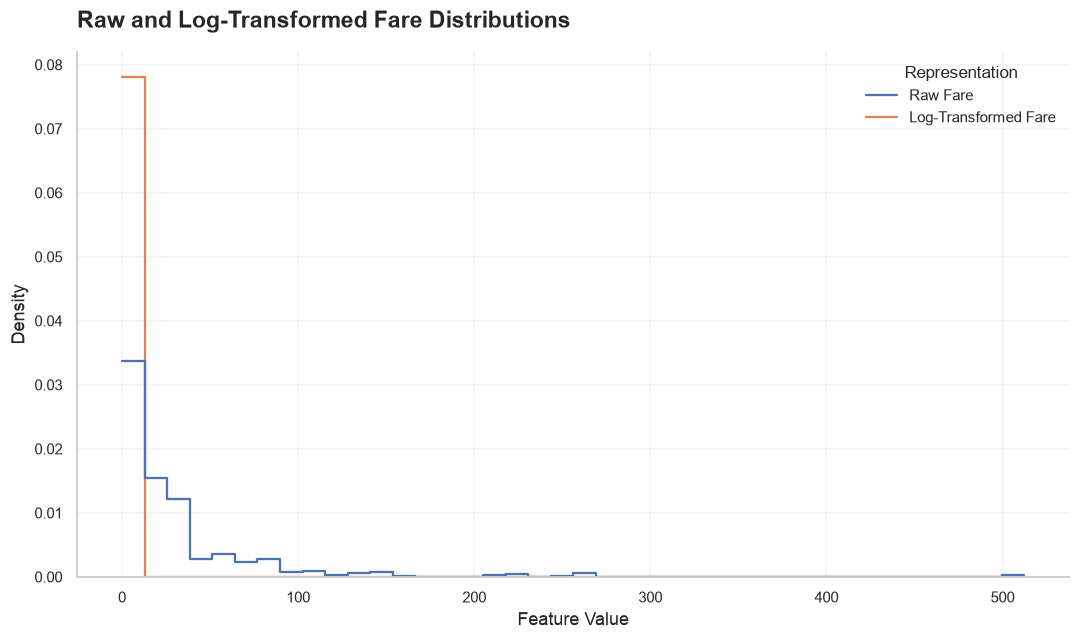

In [7]:
# ==========================================================
# Raw and log-transformed fare distributions
# ==========================================================

fare_plot_data = df[["Fare"]].copy()

fare_plot_data["Fare"] = pd.to_numeric(
    fare_plot_data["Fare"],
    errors="coerce",
)

fare_plot_data["FareLog"] = np.log1p(
    fare_plot_data["Fare"].clip(lower=0)
)

fare_plot = (
    fare_plot_data[
        ["Fare", "FareLog"]
    ]
    .melt(
        var_name="Representation",
        value_name="Value",
    )
    .dropna(subset=["Value"])
)

fare_plot["Representation"] = (
    fare_plot["Representation"]
    .replace(
        {
            "Fare": "Raw Fare",
            "FareLog": "Log-Transformed Fare",
        }
    )
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=fare_plot,
    x="Value",
    hue="Representation",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    fill=False,
)

finish_plot(
    title="Raw and Log-Transformed Fare Distributions",
    xlabel="Feature Value",
    ylabel="Density",
    legend_title="Representation",
)

## 3.3 Why Transform Fare?

The raw Fare variable is strongly right-skewed. Most passengers paid relatively modest fares, while a small number paid exceptionally high prices.

Strong skewness can make it difficult for some models to use the variable effectively because extreme observations dominate its numerical scale.

The transformation

\[
\text{FareLog} = \log(1 + \text{Fare})
\]

compresses the upper tail while preserving the ordering of observations.

Both the original Fare and its logarithmic transformation are retained during feature engineering because different models may benefit from different representations.

Passenger Class,Passengers,Mean,Median,Standard Deviation,Minimum,Maximum
1,186,38.23,37.00,14.80,0.92,80.00
2,173,29.88,29.00,14.00,0.67,70.00
3,355,25.14,24.00,12.50,0.42,74.00


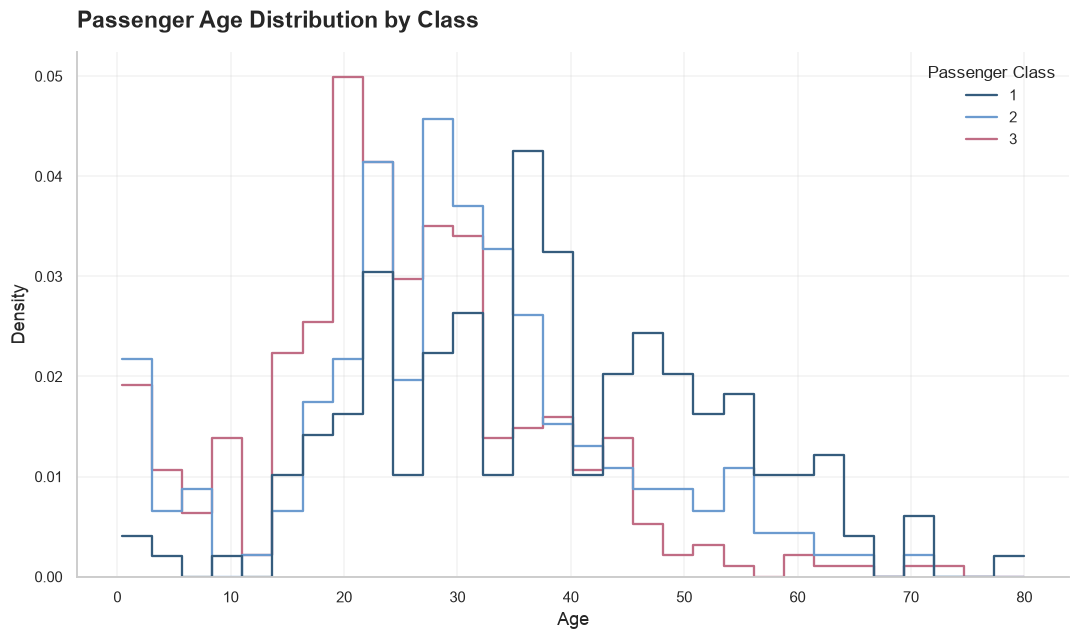

In [8]:
# ==========================================================
# Passenger age distribution
# ==========================================================

age_summary = (
    df.groupby("Pclass")["Age"]
    .agg(
        Passengers="count",
        Mean="mean",
        Median="median",
        Standard_Deviation="std",
        Minimum="min",
        Maximum="max",
    )
    .reindex(CLASS_ORDER)
    .reset_index()
    .rename(
        columns={
            "Pclass": "Passenger Class",
            "Standard_Deviation": "Standard Deviation",
        }
    )
)

display_section_table(
    age_summary,
    caption="Age Summary by Passenger Class",
    decimals=2,
    integer_columns=["Passenger Class", "Passengers"],
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Pclass",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    fill=False,
)

finish_plot(
    title="Passenger Age Distribution by Class",
    xlabel="Age",
    ylabel="Density",
    legend_title="Passenger Class",
)

## 3.4 Age Patterns

Age provides useful demographic information, although its relationship with passenger class is weaker than the relationship between Fare and passenger class.

First-class passengers tend to be older on average, while third class contains a larger concentration of younger passengers and children.

Age also contains missing values in the original Titanic data. Rather than discarding incomplete rows, the preprocessing pipeline later imputes missing ages using statistics learned only from the training data. This prevents information leakage from the validation or test sets.

Sex,1,2,3
female,94,76,144
male,122,108,347


Sex,1,2,3
female,29.9,24.2,45.9
male,21.1,18.7,60.1


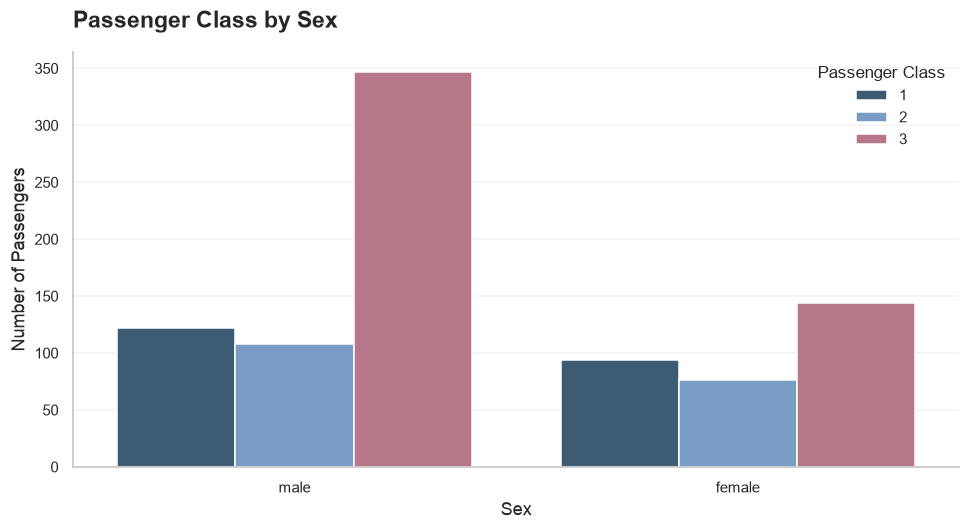

In [9]:
# ==========================================================
# Sex and passenger class
# ==========================================================

sex_class_counts = (
    pd.crosstab(
        df["Sex"],
        df["Pclass"],
    )
    .reindex(columns=CLASS_ORDER, fill_value=0)
)

sex_class_percentages = (
    sex_class_counts
    .div(
        sex_class_counts.sum(axis=1),
        axis=0,
    )
    .mul(100)
)

display_section_table(
    sex_class_counts
    .reset_index()
    .rename_axis(None, axis=1),
    caption="Passenger Counts by Sex and Class",
    integer_columns=CLASS_ORDER,
)

display_section_table(
    sex_class_percentages
    .reset_index()
    .rename_axis(None, axis=1),
    caption="Within-Sex Passenger-Class Percentages",
    decimals=1,
)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Pclass",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
)

finish_plot(
    title="Passenger Class by Sex",
    xlabel="Sex",
    ylabel="Number of Passengers",
    legend_title="Passenger Class",
)

## 3.5 Sex and Passenger Class

Sex is not a direct measure of socioeconomic status, but the passenger-class composition differs between male and female passengers.

This association may reflect historical travel patterns, family structures, employment, migration, and access to expensive accommodation.

Sex can therefore contribute predictive information when combined with stronger variables such as Fare, CabinDeck, Title, and TicketPrefix. It should not, however, be interpreted as a causal determinant of passenger class.

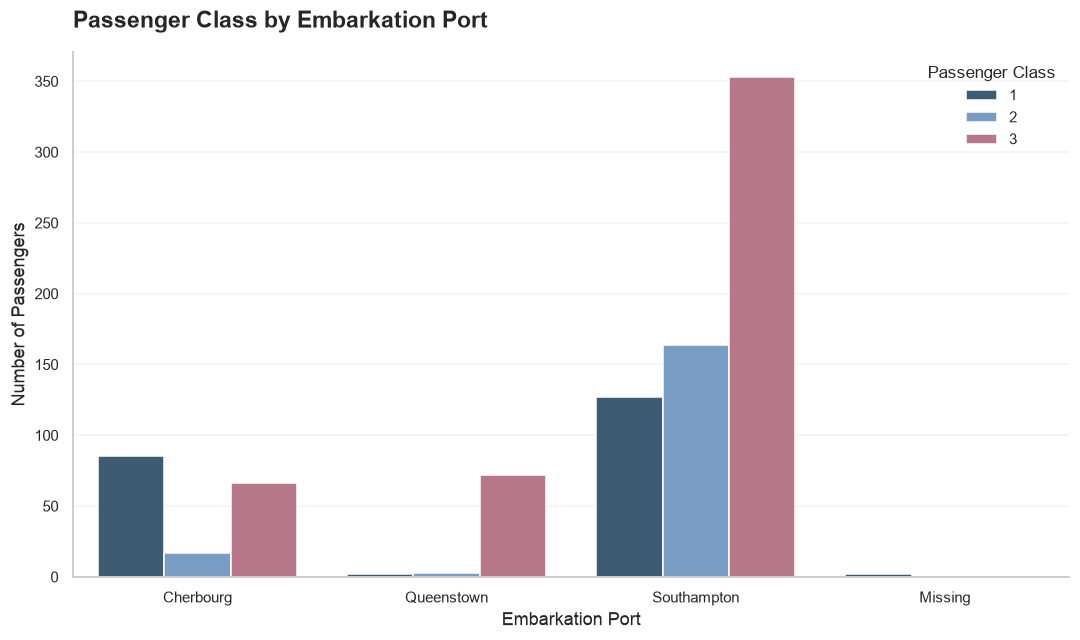

In [10]:
# ==========================================================
# Embarkation port and passenger class
# ==========================================================

embarked_labels = {
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton",
}

embarked_plot = df.copy()

embarked_plot["EmbarkedLabel"] = (
    embarked_plot["Embarked"]
    .map(embarked_labels)
    .fillna("Missing")
)

embarked_order = [
    "Cherbourg",
    "Queenstown",
    "Southampton",
    "Missing",
]

embarked_order = [
    value
    for value in embarked_order
    if value in embarked_plot["EmbarkedLabel"].unique()
]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=embarked_plot,
    x="EmbarkedLabel",
    order=embarked_order,
    hue="Pclass",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
)

finish_plot(
    title="Passenger Class by Embarkation Port",
    xlabel="Embarkation Port",
    ylabel="Number of Passengers",
    legend_title="Passenger Class",
)

## 3.6 Embarkation Port

Passenger-class proportions vary across embarkation ports.

Cherbourg, Queenstown, and Southampton served different passenger populations and routes. As a result, the embarkation variable contains indirect information about passenger wealth and travel circumstances.

Embarked is therefore included as a categorical feature in the final preprocessing pipeline. Missing values are imputed using the most frequent category observed in the training data.

# 3.7 Family Structure

Travelling with family was common aboard the Titanic.

The original dataset records:

- **SibSp** – Number of siblings and spouses aboard
- **Parch** – Number of parents and children aboard

From these variables, the preprocessing pipeline constructs two additional features:

- **FamilySize**
- **IsAlone**

These variables summarize a passenger's travelling group and can provide useful contextual information beyond the original counts.

FamilySizeGroup,1,2,3
Alone,109,104,324
Small Family,101,78,113
Large Family,6,2,54


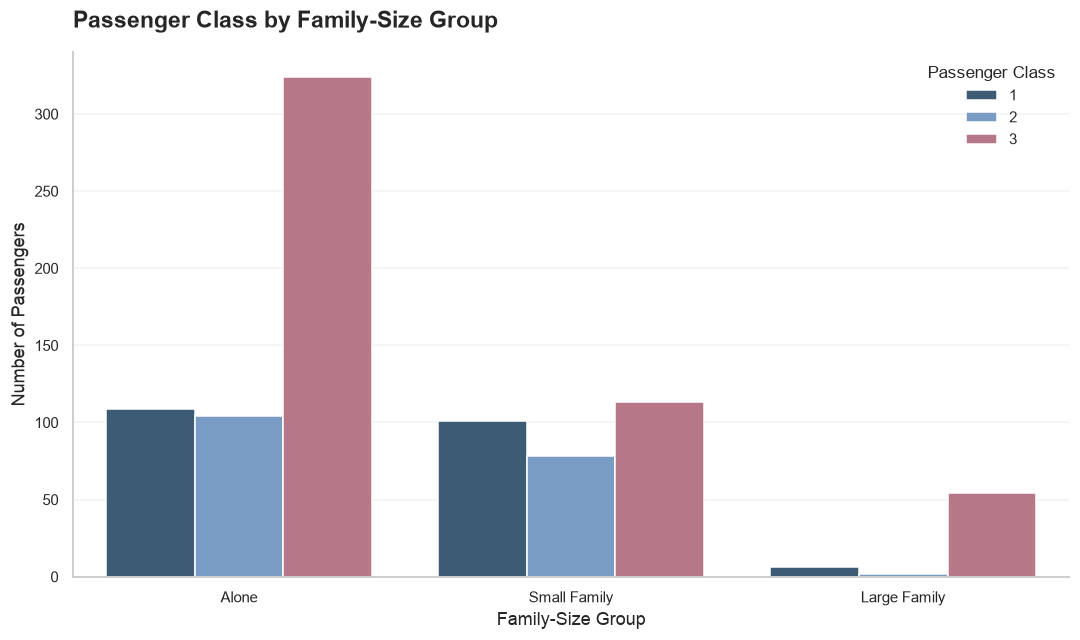

In [11]:
# ==========================================================
# Family-size groups
# ==========================================================


# ==========================================================
# Ensure FamilySize and FamilySizeGroup exist
# ==========================================================

if "FamilySize" not in df.columns:
    df["FamilySize"] = (
        df["SibSp"].fillna(0)
        + df["Parch"].fillna(0)
        + 1
    )

if "FamilySizeGroup" not in df.columns:

    df["FamilySizeGroup"] = pd.cut(
        df["FamilySize"],
        bins=[0, 1, 4, np.inf],
        labels=[
            "Alone",
            "Small Family",
            "Large Family",
        ],
        include_lowest=True,
    )


family_group_order = [
    "Alone",
    "Small Family",
    "Large Family",
]

family_group_counts = (
    pd.crosstab(
        df["FamilySizeGroup"],
        df["Pclass"],
    )
    .reindex(
        index=family_group_order,
        columns=CLASS_ORDER,
        fill_value=0,
    )
)

display_section_table(
    family_group_counts
    .reset_index()
    .rename_axis(None, axis=1),
    caption="Passenger Class by Family-Size Group",
    integer_columns=CLASS_ORDER,
)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="FamilySizeGroup",
    order=family_group_order,
    hue="Pclass",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
)

finish_plot(
    title="Passenger Class by Family-Size Group",
    xlabel="Family-Size Group",
    ylabel="Number of Passengers",
    legend_title="Passenger Class",
)

## Interpretation

Rather than relying only on the original SibSp and Parch variables, combining them into FamilySize produces a more intuitive representation of a passenger's travelling party.

A binary indicator (IsAlone) further summarizes whether a passenger travelled independently or with relatives.

These engineered variables often capture relationships that are easier for machine learning models to exploit than the original variables separately.

# 3.8 Cabin Information

Cabin information is incomplete for many passengers.

Nevertheless, cabin-related variables contain valuable socioeconomic information because passengers travelling in higher classes were substantially more likely to have recorded cabin assignments.

Instead of discarding the Cabin column, the preprocessing pipeline extracts:

- Cabin deck
- Cabin availability
- Number of cabins listed

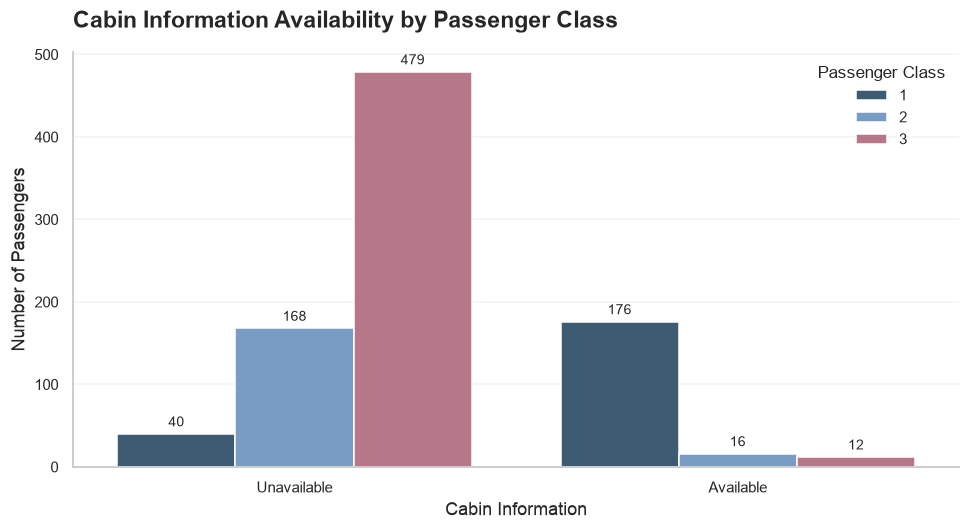

In [12]:
# ==========================================================
# Cabin availability
# ==========================================================

# Ensure HasCabin exists
if "HasCabin" not in df.columns:

    if "Cabin" in df.columns:

        df["HasCabin"] = (
            df["Cabin"]
            .notna()
            .astype(int)
        )

    else:

        raise KeyError(
            "Neither 'HasCabin' nor the original 'Cabin' column exists."
        )

cabin_plot = df.copy()

cabin_plot["Cabin Information"] = cabin_plot["HasCabin"].map(
    {
        0: "Unavailable",
        1: "Available",
    }
)

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=cabin_plot,
    x="Cabin Information",
    hue="Pclass",
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
)

add_bar_labels(ax)

finish_plot(
    title="Cabin Information Availability by Passenger Class",
    xlabel="Cabin Information",
    ylabel="Number of Passengers",
    legend_title="Passenger Class",
)

## Interpretation

Cabin information is highly incomplete, but the missingness itself is informative.

Passengers travelling in higher classes were considerably more likely to have cabin assignments recorded.

Rather than treating missing cabin values as unusable, the preprocessing pipeline converts them into meaningful categorical features while preserving the information contained in the missingness pattern.

# 3.9 Ticket Characteristics

Ticket numbers are not arbitrary identifiers.

Many tickets contain alphabetic prefixes corresponding to booking offices, ticket series, or issuing agencies.

The preprocessing pipeline extracts these prefixes as categorical variables that may capture information associated with passenger class.

,Count
TicketPrefix,
NONE,661
PC,60
CA,41
A,28
STONO,18
SOTONOQ,15
WC,10
SCPARIS,7
SOC,6


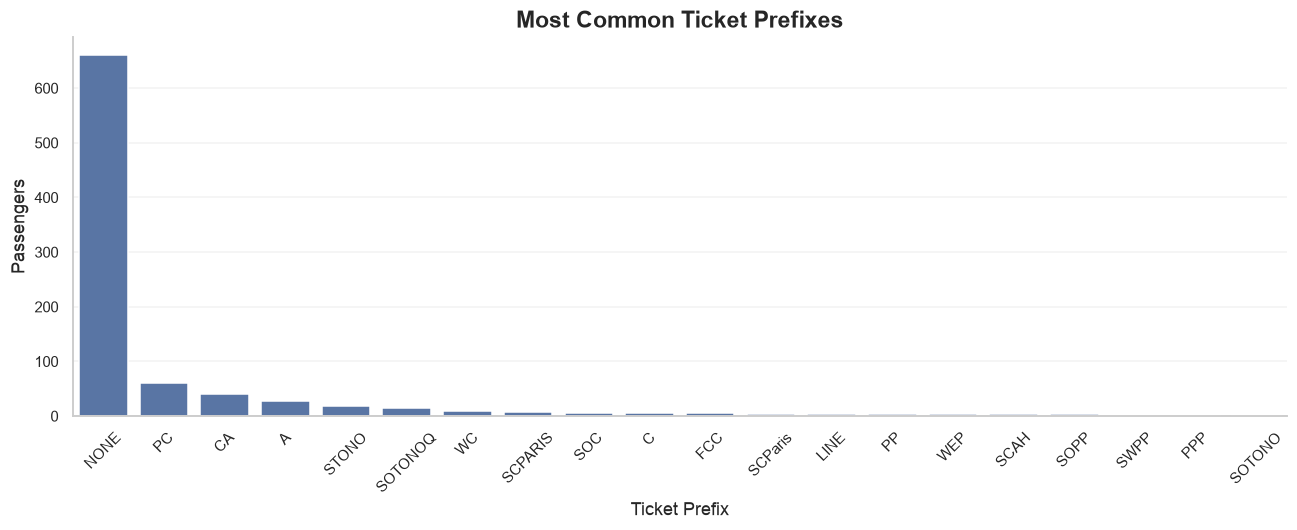

In [13]:
# ==========================================================
# Ticket prefixes
# ==========================================================

ticket_df = df.copy()

ticket_df["TicketPrefix"] = (
    ticket_df["Ticket"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace("/", "", regex=False)
    .str.extract(r"([A-Za-z]+)")
    .fillna("NONE")
)

prefix_counts = (
    ticket_df["TicketPrefix"]
    .value_counts()
    .head(20)
)

display(prefix_counts.to_frame("Count"))

plt.figure(figsize=(12,5))

sns.barplot(
    x=prefix_counts.index,
    y=prefix_counts.values
)

plt.title(
    "Most Common Ticket Prefixes",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.xlabel("Ticket Prefix")

plt.ylabel("Passengers")

plt.tight_layout()

plt.show()

## Interpretation

Although ticket numbers appear unstructured at first glance, their prefixes contain useful categorical information.

Machine learning models cannot directly exploit arbitrary ticket strings, but extracted prefixes allow recurring ticket patterns to contribute predictive information.

This is an example of feature engineering transforming raw textual data into a machine-learning-friendly representation.

# 3.10 Missing Values

Understanding missing data is an essential step in any machine learning project.

Rather than removing incomplete observations, this project uses an explicit preprocessing pipeline that imputes missing values using statistics calculated exclusively from the training data.

This strategy preserves valuable observations while preventing information leakage into validation and test sets.

Feature,Missing Values,Missing Percentage
Cabin,687,77.1%
Age,177,19.9%
Embarked,2,0.2%


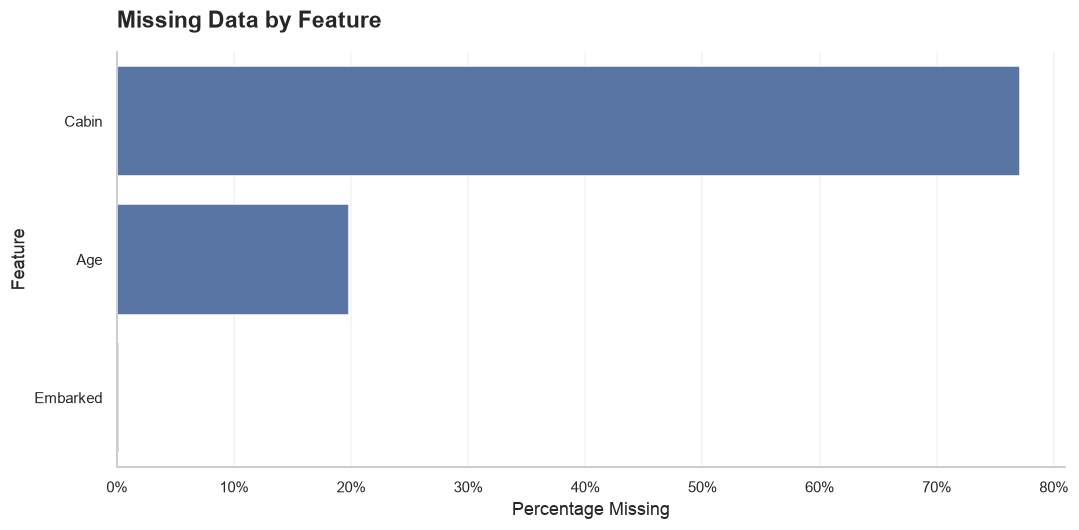

In [14]:
# ==========================================================
# Missing-value summary
# ==========================================================

missing_summary = pd.DataFrame(
    {
        "Missing Values": df.isna().sum(),
        "Missing Percentage": df.isna().mean(),
    }
)

missing_summary = (
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
    .sort_values(
        "Missing Percentage",
        ascending=False,
    )
    .reset_index()
    .rename(columns={"index": "Feature"})
)

if missing_summary.empty:

    print("No missing values remain in the processed dataset.")

else:

    display_section_table(
        missing_summary,
        caption="Missing-Value Summary",
        percent_columns=["Missing Percentage"],
        integer_columns=["Missing Values"],
    )

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=missing_summary,
        x="Missing Percentage",
        y="Feature",
    )

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _: f"{value:.0%}"
        )
    )

    finish_plot(
        title="Missing Data by Feature",
        xlabel="Percentage Missing",
        ylabel="Feature",
    )

# EDA Summary

The exploratory analysis reveals several important characteristics of the dataset.

Key observations include:

- Passenger class is moderately imbalanced.
- Fare is one of the strongest predictors of passenger class.
- Age contributes useful demographic information but contains missing values.
- Cabin information is sparse, yet highly informative.
- Ticket prefixes provide additional categorical structure.
- Family-related variables can be summarized through feature engineering.
- Missing values can be handled through systematic preprocessing rather than row deletion.

These findings motivate the feature engineering strategy developed in the next section, where raw variables are transformed into representations that improve model performance while maintaining reproducibility.

# 4. Feature Engineering

Feature engineering is one of the most important stages of the machine learning workflow.

Raw datasets often contain variables that are incomplete, overly granular, or difficult for machine learning algorithms to interpret directly.

The objective of feature engineering is to transform the original variables into representations that better capture the underlying structure of the data while preserving interpretability.

For this project, the feature engineering pipeline creates several additional variables derived from the original Titanic dataset.

The engineered features include:

- Passenger title
- Family size
- Travelling alone indicator
- Log-transformed fare
- Cabin deck
- Cabin count
- Ticket prefix
- Family size category

These features are generated automatically inside the preprocessing pipeline, ensuring that identical transformations are applied during training, validation, testing, and prediction.

In [15]:
# ==========================================================
# Feature engineering demonstration
# ==========================================================

feature_demo = df.copy()

# -------------------------------
# Passenger title
# -------------------------------

feature_demo["Title"] = (
    feature_demo["Name"]
    .str.extract(r",\s*([^\.]+)\.")
)

# -------------------------------
# Family size
# -------------------------------

feature_demo["FamilySize"] = (
    feature_demo["SibSp"]
    + feature_demo["Parch"]
    + 1
)

feature_demo["IsAlone"] = (
    feature_demo["FamilySize"] == 1
)

# -------------------------------
# Log fare
# -------------------------------

feature_demo["FareLog"] = np.log1p(feature_demo["Fare"])

# -------------------------------
# Cabin deck
# -------------------------------

feature_demo["CabinDeck"] = (
    feature_demo["Cabin"]
    .fillna("Unknown")
    .astype(str)
    .str[0]
)

# -------------------------------
# Ticket prefix
# -------------------------------

feature_demo["TicketPrefix"] = (
    feature_demo["Ticket"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace("/", "", regex=False)
    .str.extract(r"([A-Za-z]+)")
    .fillna("NONE")
)

display(

    feature_demo[
        [
            "Name",
            "Title",
            "Fare",
            "FareLog",
            "FamilySize",
            "IsAlone",
            "Cabin",
            "CabinDeck",
            "Ticket",
            "TicketPrefix",
        ]
    ].head(10)

)

,Name,Title,Fare,FareLog,FamilySize,IsAlone,Cabin,CabinDeck,Ticket,TicketPrefix
0,"Braund, Mr. Owen Harris",Mr,7.250,2.110,2,False,NaN,U,A/5 21171,A
1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mrs,71.283,4.281,2,False,C85,C,PC 17599,PC
2,"Heikkinen, Miss. Laina",Miss,7.925,2.189,1,True,NaN,U,STON/O2. 3101282,STONO
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,53.100,3.991,2,False,C123,C,113803,NONE
4,"Allen, Mr. William Henry",Mr,8.050,2.203,1,True,NaN,U,373450,NONE
5,"Moran, Mr. James",Mr,8.458,2.247,1,True,NaN,U,330877,NONE
6,"McCarthy, Mr. Timothy J",Mr,51.862,3.968,1,True,E46,E,17463,NONE
7,"Palsson, Master. Gosta Leonard",Master,21.075,3.094,5,False,NaN,U,349909,NONE
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,11.133,2.496,3,False,NaN,U,347742,NONE
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,30.071,3.436,2,False,NaN,U,237736,NONE


## 4.1 Passenger Titles

Passenger names contain valuable social information.

For example:

- Mr
- Mrs
- Miss
- Master
- Dr
- Rev
- Col

Rather than treating the full passenger name as text, the preprocessing pipeline extracts the title.

Titles capture demographic and socioeconomic information while dramatically reducing dimensionality.

For example:

| Original Name | Extracted Title |
|---------------|----------------|
| Braund, Mr. Owen Harris | Mr |
| Cumings, Mrs. John Bradley | Mrs |
| Heikkinen, Miss. Laina | Miss |

This transformation converts a nearly unique text variable into a compact categorical feature suitable for machine learning.

,Passengers
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Major,2
Mlle,2
Col,2


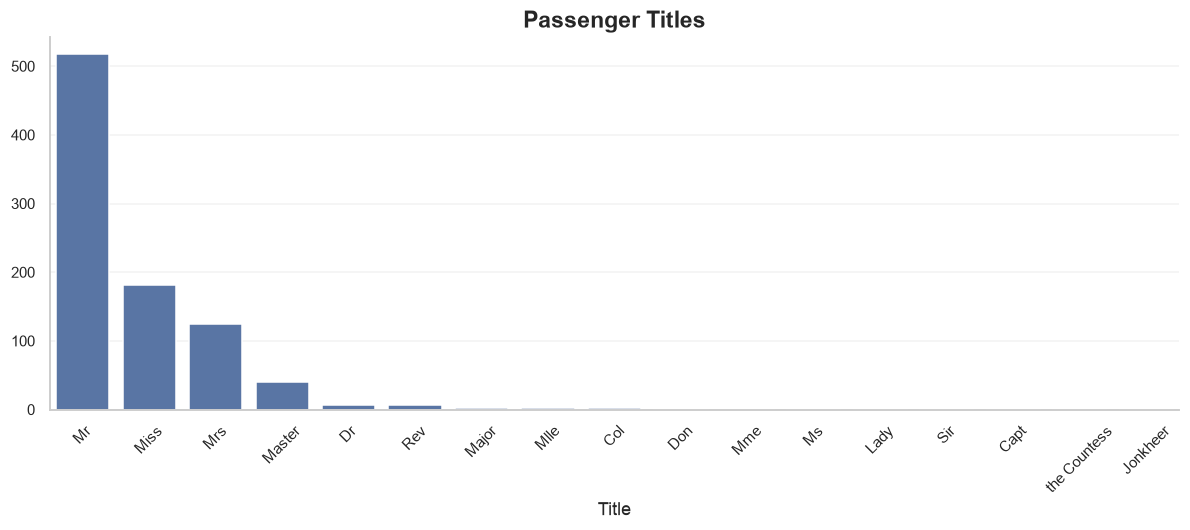

In [16]:
# ==========================================================
# Passenger titles
# ==========================================================

title_counts = (
    feature_demo["Title"]
    .value_counts()
)

display(title_counts.to_frame("Passengers"))

plt.figure(figsize=(11,5))

sns.barplot(
    x=title_counts.index,
    y=title_counts.values
)

plt.title(
    "Passenger Titles",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 4.2 Family Features

The original dataset provides two related variables:

- SibSp
- Parch

Although informative, these variables are easier to interpret when combined into a single measure representing the passenger's travelling group.

The preprocessing pipeline therefore creates:

- FamilySize
- IsAlone

These variables reduce complexity while preserving the essential information contained in the original family variables.

,SibSp,Parch,FamilySize,FamilySizeGroup
0,1,0,2,Small Family
1,1,0,2,Small Family
2,0,0,1,Alone
3,1,0,2,Small Family
4,0,0,1,Alone
5,0,0,1,Alone
6,0,0,1,Alone
7,3,1,5,Large Family
8,0,2,3,Small Family
9,1,0,2,Small Family


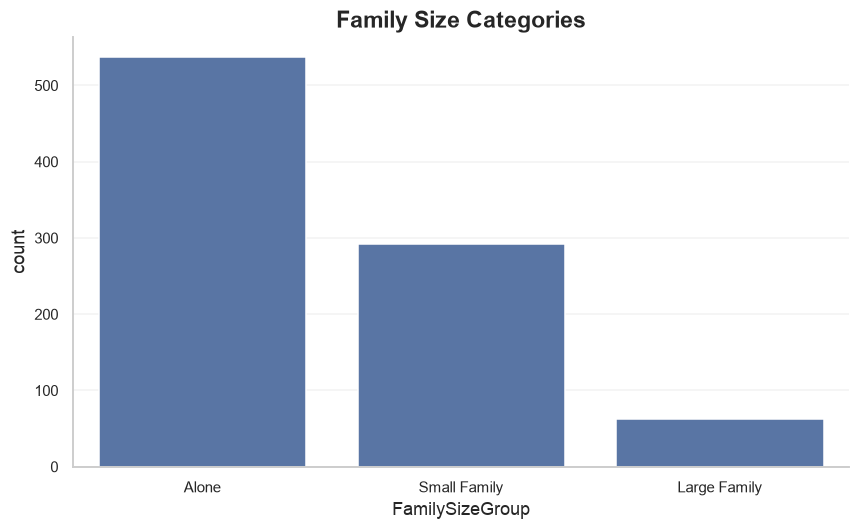

In [17]:
# ==========================================================
# Family size categories
# ==========================================================

feature_demo["FamilySizeGroup"] = pd.cut(

    feature_demo["FamilySize"],

    bins=[0,1,4,20],

    labels=[
        "Alone",
        "Small Family",
        "Large Family",
    ]

)

display(

    feature_demo[
        [
            "SibSp",
            "Parch",
            "FamilySize",
            "FamilySizeGroup",
        ]
    ].head(12)

)

plt.figure(figsize=(8,5))

sns.countplot(

    data=feature_demo,

    x="FamilySizeGroup",

)

plt.title(
    "Family Size Categories",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 4.3 Logarithmic Fare Transformation

Ticket fares vary substantially across passengers.

Rather than relying solely on the raw Fare variable, the preprocessing pipeline additionally computes

**FareLog = log(1 + Fare)**

This transformation compresses extremely large ticket prices while preserving their ordering.

Using both Fare and FareLog allows tree-based models to exploit information from both the original and transformed scales.

,Fare,FareLog
0,7.250,2.110
1,71.283,4.281
2,7.925,2.189
3,53.100,3.991
4,8.050,2.203
5,8.458,2.247
6,51.862,3.968
7,21.075,3.094
8,11.133,2.496
9,30.071,3.436


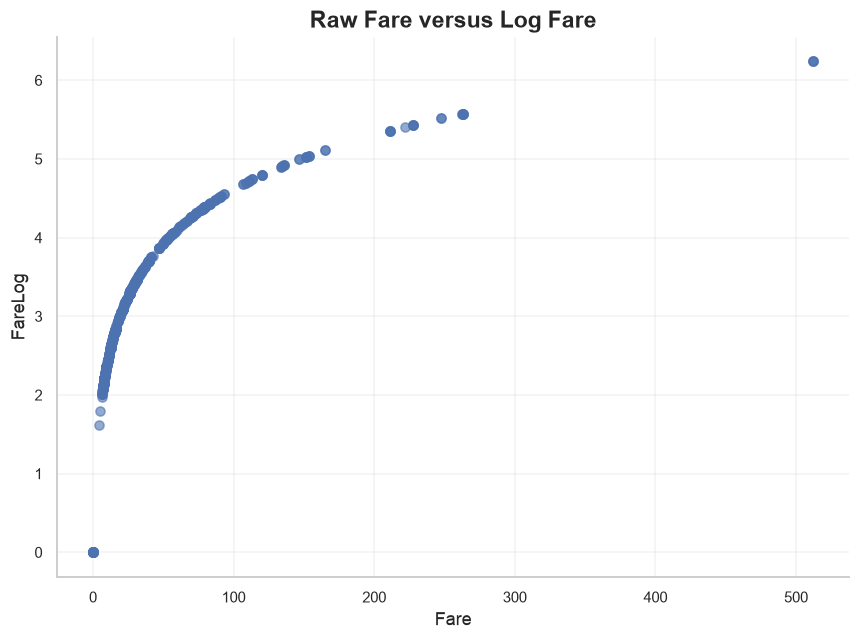

In [18]:
# ==========================================================
# Fare transformation example
# ==========================================================

comparison = feature_demo[
    [
        "Fare",
        "FareLog",
    ]
].copy()

display(comparison.head(15))

plt.figure(figsize=(8,6))

plt.scatter(

    comparison["Fare"],

    comparison["FareLog"],

    alpha=0.6

)

plt.title(
    "Raw Fare versus Log Fare",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fare")

plt.ylabel("FareLog")

plt.tight_layout()

plt.show()

## 4.4 Why Feature Engineering Matters

Feature engineering converts raw observations into representations that are more informative for machine learning algorithms.

Rather than memorizing individual passenger records, the model learns meaningful patterns such as:

- passengers travelling alone
- family size
- social status
- ticket characteristics
- cabin location
- fare scale

These transformations improve predictive performance while remaining interpretable and reproducible.

Because all transformations are implemented inside the preprocessing pipeline, exactly the same feature engineering steps are applied during model training, testing, and deployment.

# 5. Machine Learning Pipeline

Modern machine learning projects involve much more than fitting an algorithm to a dataset.

A complete pipeline should:

- Validate the input data
- Handle missing values
- Encode categorical variables
- Scale numerical variables when appropriate
- Engineer new features
- Prevent information leakage
- Produce reproducible predictions

This project implements the entire workflow using reusable Python modules and scikit-learn pipelines, ensuring that identical preprocessing steps are applied during training, evaluation, and deployment.

In [19]:
# ==========================================================
# Features used for model development
# ==========================================================

feature_columns = [
    "Age",
    "Sex",
    "Fare",
    "Embarked",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "CabinDeck",
    "CabinCount",
    "FareLog",
    "Title",
    "TicketPrefix",
    "FamilySizeGroup",
]

target_column = "Pclass"

print("=" * 80)
print("Predictor Variables")
print("=" * 80)

for feature in feature_columns:
    print(f"• {feature}")

print("\nTarget Variable")
print("----------------")
print(target_column)

print("\n")

print("Number of predictor variables:", len(feature_columns))

Predictor Variables
• Age
• Sex
• Fare
• Embarked
• SibSp
• Parch
• FamilySize
• IsAlone
• HasCabin
• CabinDeck
• CabinCount
• FareLog
• Title
• TicketPrefix
• FamilySizeGroup

Target Variable
----------------
Pclass


Number of predictor variables: 15


## 5.1 Predictor Variables

The final model combines numerical, categorical, and engineered variables.

The feature set intentionally excludes variables that would introduce information leakage.

For example, the **Survived** variable is strongly associated with passenger class, but it was deliberately omitted because survival occurred after the passenger's class had already been determined.

The final predictor set therefore consists only of information that could reasonably be available independently of the voyage outcome.

## 5.2 Preprocessing Strategy

Different variable types require different preprocessing strategies.

### Numerical Features

- Median imputation
- Scaling when appropriate

### Categorical Features

- Missing-value imputation
- One-hot encoding

This separation is implemented using scikit-learn's **ColumnTransformer**, allowing all preprocessing steps to be learned exclusively from the training data.

As a result, no information from the validation or test sets leaks into the training process.

In [20]:
# ==========================================================
# Numerical versus categorical variables
# ==========================================================

numerical_features = [
    "Age",
    "Fare",
    "FareLog",
    "SibSp",
    "Parch",
    "FamilySize",
    "CabinCount",
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "CabinDeck",
    "TicketPrefix",
    "FamilySizeGroup",
    "HasCabin",
    "IsAlone",
]

summary = pd.DataFrame({
    "Feature": numerical_features + categorical_features,
    "Type": (
        ["Numerical"] * len(numerical_features)
        +
        ["Categorical"] * len(categorical_features)
    )
})

display(summary)

,Feature,Type
0,Age,Numerical
1,Fare,Numerical
2,FareLog,Numerical
3,SibSp,Numerical
4,Parch,Numerical
5,FamilySize,Numerical
6,CabinCount,Numerical
7,Sex,Categorical
8,Embarked,Categorical
9,Title,Categorical


## 5.3 Preventing Data Leakage

Data leakage occurs when information from the validation or test data influences model training.

This project avoids leakage by ensuring that:

- Missing-value imputation is fitted only on the training data.
- Encoders learn categories only from the training data.
- Scaling parameters are estimated only from the training data.
- Feature engineering is applied consistently across all datasets.

This approach more closely reflects how machine learning models operate in production environments.

## 5.4 Candidate Models

Several machine learning algorithms were evaluated during model development.

The objective was not simply to maximize accuracy, but to identify a model that generalized well and produced stable performance across cross-validation folds.

The candidate models included:

- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradientBoosting
- CatBoost

Each model was evaluated using identical preprocessing and validation procedures.

In [21]:
# ==========================================================
# Polished model-comparison table
# ==========================================================

comparison_candidates = [
    METRICS_DIR / "model_comparison.csv",
    ARTIFACTS_DIR / "model_comparison.csv",
]

comparison_path = next(
    (path for path in comparison_candidates if path.exists()),
    None,
)

if comparison_path is not None:

    model_comparison = pd.read_csv(comparison_path)

    rename_map = {
        column: column.replace("_", " ").title()
        for column in model_comparison.columns
    }

    model_comparison = model_comparison.rename(
        columns=rename_map
    )

    score_candidates = [
        column
        for column in model_comparison.columns
        if any(
            term in column.lower()
            for term in [
                "f1",
                "accuracy",
                "score",
                "balanced",
            ]
        )
    ]

    if score_candidates:
        model_comparison = model_comparison.sort_values(
            score_candidates[0],
            ascending=False,
        )

    print(f"Loaded from: {comparison_path}")

    display_section_table(
        model_comparison,
        caption="Cross-Validated Candidate Model Performance",
        decimals=4,
    )

else:

    print("Model comparison file was not found.")
    print("Checked:")

    for path in comparison_candidates:
        print(f"  - {path}")

Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/metrics/model_comparison.csv


Model,Cv Accuracy Mean,Cv Accuracy Std,Cv Balanced Accuracy Mean,Cv Balanced Accuracy Std,Cv F1 Macro Mean,Cv F1 Macro Std,Fit Time Mean,Score Time Mean
random_forest,0.9185,0.0268,0.9278,0.0176,0.9088,0.0258,1.6145,0.1546
logistic_regression,0.8342,0.0253,0.8358,0.0225,0.8221,0.0223,0.0612,0.0201
dummy,0.5506,0.0015,0.3333,0.0000,0.2367,0.0004,0.0733,0.0225


## 5.5 Model Selection

After comparing multiple algorithms, the Random Forest classifier was selected as the final production model.

Several characteristics make Random Forest particularly suitable for this problem:

- Handles nonlinear relationships.
- Naturally captures feature interactions.
- Requires relatively little preprocessing.
- Is robust to outliers.
- Provides estimates of feature importance.
- Generalizes well on mixed numerical and categorical datasets.

These properties make Random Forest an effective baseline for structured tabular data.

In [22]:
# ==========================================================
# Final model metadata
# ==========================================================

metadata_candidates = [
    METRICS_DIR / "model_metadata.json",
    ARTIFACTS_DIR / "model_metadata.json",
    MODELS_DIR / "model_metadata.json",
]

metadata_path = next(
    (path for path in metadata_candidates if path.exists()),
    None,
)

if metadata_path is not None:

    metadata = pd.read_json(
        metadata_path,
        typ="series",
    )

    print(f"Loaded from: {metadata_path}")
    display(metadata)

else:

    print("Model metadata file was not found.")
    print("Checked:")

    for path in metadata_candidates:
        print(f"  - {path}")

Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/metrics/model_metadata.json


baseline_cv_f1_macro                                                                                   0.909
best_hyperparameters         {'model__bootstrap': False, 'model__class_weight': None, 'model__max_depth':...
candidate_models                                                 [dummy, logistic_regression, random_forest]
created_at_utc                                                              2026-07-20T21:49:56.173089+00:00
cv_folds                                                                                                   5
feature_columns              [Age, SibSp, Parch, Fare, FamilySize, IsAlone, HasCabin, CabinCount, FareLog...
holdout_accuracy                                                                                       0.888
holdout_balanced_accuracy                                                                              0.860
holdout_f1_macro                                                                                       0.864
model_name         

## Pipeline Summary

The complete machine learning workflow can be summarized as follows:

1. Load and validate the cleaned dataset.
2. Apply feature engineering.
3. Separate numerical and categorical variables.
4. Impute missing values.
5. Encode categorical features.
6. Train candidate machine learning models.
7. Select the best-performing model.
8. Tune hyperparameters.
9. Evaluate on an internal hold-out test set.
10. Validate on an independent external dataset.

This modular design improves reproducibility, maintainability, and deployment readiness while reducing the risk of data leakage.

# 6. Model Training and Validation

Model development follows a structured workflow designed to estimate how well the model will generalize to unseen passengers.

Rather than evaluating a single train/test split, the workflow includes:

- Cross-validation
- Hyperparameter optimization
- Hold-out testing
- Independent external validation

This multi-stage evaluation provides a much more reliable assessment of model performance than a single accuracy score.

## 6.1 Model Development Workflow

```text
Raw Dataset
      │
      ▼
Train / Test Split
      │
      ▼
Feature Engineering
      │
      ▼
ColumnTransformer
      │
      ▼
Candidate Models
      │
      ▼
Cross Validation
      │
      ▼
Hyperparameter Tuning
      │
      ▼
Final Random Forest
      │
      ├────────► Hold-out Test Set
      │
      └────────► External Validation Dataset
```

Every preprocessing step is learned exclusively from the training data, preventing information leakage into later evaluation stages.

## 6.2 Cross-Validation

Cross-validation estimates how well a model is expected to perform on unseen data.

Instead of relying on one train/test split, the training data are divided into several folds.

For each iteration:

1. One fold is held out.
2. The remaining folds are used for training.
3. Performance is measured on the held-out fold.

The reported performance is the average across all folds.

This reduces the influence of any single random split and provides a more stable estimate of model quality.

In [23]:
# ==========================================================
# Cross-validation results
# ==========================================================

cv_candidates = [
    METRICS_DIR / "model_comparison.csv",
    ARTIFACTS_DIR / "model_comparison.csv",
]

cv_path = next(
    (path for path in cv_candidates if path.exists()),
    None,
)

if cv_path is not None:

    cv_results = pd.read_csv(cv_path)

    print(f"Loaded from: {cv_path}")
    display(cv_results)

else:

    print("Cross-validation results were not found.")
    print("Checked:")

    for path in cv_candidates:
        print(f"  - {path}")

Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/metrics/model_comparison.csv


,model,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,fit_time_mean,score_time_mean
0,random_forest,0.919,0.027,0.928,0.018,0.909,0.026,1.615,0.155
1,logistic_regression,0.834,0.025,0.836,0.023,0.822,0.022,0.061,0.020
2,dummy,0.551,0.002,0.333,0.000,0.237,0.000,0.073,0.023


## 6.3 Hyperparameter Optimization

Machine learning algorithms contain parameters that influence their behaviour.

For Random Forest these include:

- Number of trees
- Maximum tree depth
- Minimum samples per split
- Minimum samples per leaf
- Maximum features considered during splitting

Rather than selecting these manually, the project performs automated hyperparameter optimization.

The resulting model balances predictive performance with robustness and generalization.

In [24]:
# ==========================================================
# Final model metadata
# ==========================================================

metadata_candidates = [
    METRICS_DIR / "model_metadata.json",
    ARTIFACTS_DIR / "model_metadata.json",
    MODELS_DIR / "model_metadata.json",
]

metadata_path = next(
    (path for path in metadata_candidates if path.exists()),
    None,
)

if metadata_path is not None:

    metadata = pd.read_json(
        metadata_path,
        typ="series",
    )

    print(f"Loaded from: {metadata_path}")
    display(metadata)

else:

    print("Model metadata file was not found.")
    print("Checked:")

    for path in metadata_candidates:
        print(f"  - {path}")

Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/metrics/model_metadata.json


baseline_cv_f1_macro                                                                                   0.909
best_hyperparameters         {'model__bootstrap': False, 'model__class_weight': None, 'model__max_depth':...
candidate_models                                                 [dummy, logistic_regression, random_forest]
created_at_utc                                                              2026-07-20T21:49:56.173089+00:00
cv_folds                                                                                                   5
feature_columns              [Age, SibSp, Parch, Fare, FamilySize, IsAlone, HasCabin, CabinCount, FareLog...
holdout_accuracy                                                                                       0.888
holdout_balanced_accuracy                                                                              0.860
holdout_f1_macro                                                                                       0.864
model_name         

## 6.4 Why Random Forest?

Random Forest was selected because it consistently achieved the strongest overall balance between predictive performance and robustness.

Its advantages include:

- Excellent performance on structured tabular datasets.
- Ability to model nonlinear relationships.
- Natural handling of feature interactions.
- Resistance to overfitting through ensemble averaging.
- Minimal assumptions regarding variable distributions.
- Straightforward interpretation through feature importance.

These characteristics make Random Forest an excellent production baseline for tabular classification problems.

# 7. Internal Hold-Out Evaluation

The final model was evaluated on the held-out portion of the original Titanic training data.

This section reads the saved evaluation artifact rather than retraining the model inside the notebook. Scalar metrics are displayed in a table, while the confusion matrix is rendered as a proper \(3 	imes 3\) heatmap.


Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/metrics/test_metrics.json


Metric,Score
Accuracy,0.8883
Balanced Accuracy,0.8600
F1 Macro,0.8641
Test Rows,179.0000


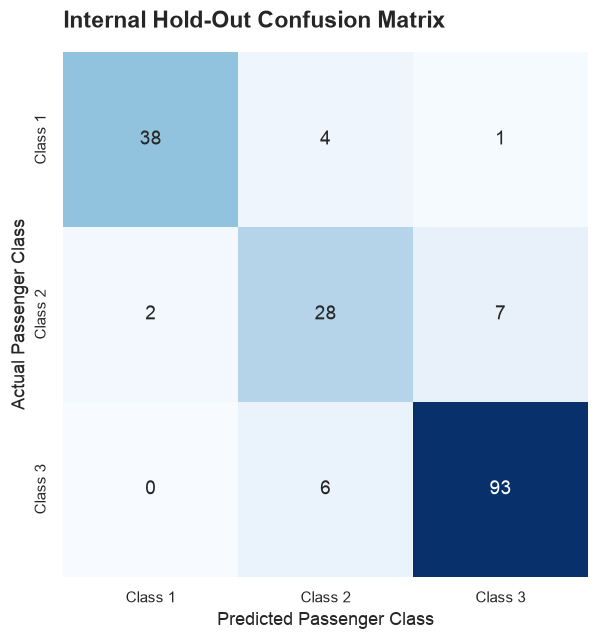

In [25]:
# ==========================================================
# Internal hold-out metrics and confusion matrix
# ==========================================================

import json

internal_metrics_path = METRICS_DIR / "test_metrics.json"

if not internal_metrics_path.exists():
    raise FileNotFoundError(
        "Internal metrics were not found at:\n"
        f"{internal_metrics_path}"
    )

with internal_metrics_path.open("r", encoding="utf-8") as file:
    internal_metrics_raw = json.load(file)

print(f"Loaded from: {internal_metrics_path}")

# Keep only scalar numeric values in the metrics table.
internal_scalar_metrics = {
    key: value
    for key, value in internal_metrics_raw.items()
    if isinstance(value, (int, float))
    and not isinstance(value, bool)
}

internal_metrics_table = pd.DataFrame(
    {
        "Metric": [
            key.replace("_", " ").title()
            for key in internal_scalar_metrics
        ],
        "Score": list(internal_scalar_metrics.values()),
    }
)

display_section_table(
    internal_metrics_table,
    caption="Internal Hold-Out Performance",
    decimals=4,
)

# Render the saved confusion matrix as a square heatmap.
internal_confusion_matrix = np.asarray(
    internal_metrics_raw.get("confusion_matrix", [])
)

if internal_confusion_matrix.shape == (3, 3):
    plt.figure(figsize=(7, 6))

    sns.heatmap(
        internal_confusion_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=["Class 1", "Class 2", "Class 3"],
        yticklabels=["Class 1", "Class 2", "Class 3"],
    )

    finish_plot(
        title="Internal Hold-Out Confusion Matrix",
        xlabel="Predicted Passenger Class",
        ylabel="Actual Passenger Class",
    )
else:
    print(
        "A 3 × 3 internal confusion matrix was not found "
        "inside test_metrics.json."
    )


## 7.1 Interpretation

The scalar metrics summarize overall multiclass performance, whereas the confusion matrix shows which passenger classes are confused with one another.

The diagonal cells represent correct predictions. Off-diagonal cells represent errors. This distinction is especially useful here because overall accuracy alone cannot show whether the model performs unevenly across first, second, and third class.


# 8. Independent External Validation

Internal hold-out evaluation measures performance on unseen rows from the original data source. External validation is stricter: it applies the saved model to a separately prepared Titanic dataset after removing overlapping passengers.

The repository stores the external data and evaluation outputs in:

```text
data/external/titanic_external_nonoverlap.csv
artifacts/predictions/external_nonoverlap/
```


## 8.1 External Dataset


In [26]:
# ==========================================================
# External non-overlapping dataset
# ==========================================================

external_data_path = (
    EXTERNAL_DATA_DIR
    / "titanic_external_nonoverlap.csv"
)

if not external_data_path.exists():
    raise FileNotFoundError(
        "The external validation dataset was not found at:\n"
        f"{external_data_path}"
    )

external = pd.read_csv(external_data_path)

external_summary = pd.DataFrame(
    {
        "Property": [
            "Rows",
            "Columns",
            "Target available",
            "Duplicate passenger IDs",
        ],
        "Value": [
            len(external),
            external.shape[1],
            "Pclass" in external.columns,
            (
                int(external["PassengerId"].duplicated().sum())
                if "PassengerId" in external.columns
                else "Not available"
            ),
        ],
    }
)

print(f"Loaded from: {external_data_path}")

display_section_table(
    external_summary,
    caption="External Validation Dataset",
    decimals=0,
)

display(external.head())


Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/data/external/titanic_external_nonoverlap.csv


Property,Value
Rows,771
Columns,14
Target available,True
Duplicate passenger IDs,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Country,ExternalSourceRow
0,2,0,3,"Abbott, Mr. Eugene Joseph",male,13.000,0.000,2.000,"2,673.000",20.050,NaN,S,United States,2
1,4,1,3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.000,1.000,1.000,"2,673.000",20.050,NaN,S,England,4
2,5,1,3,"Abelseth, Miss. Karen Marie",female,16.000,0.000,0.000,"348,125.000",7.130,NaN,S,Norway,5
3,6,1,3,"Abelseth, Mr. Olaus Jørgensen",male,25.000,0.000,0.000,"348,122.000",7.130,NaN,S,United States,6
4,8,1,2,"Abelson, Mrs. Hannah",female,28.000,1.000,0.000,"3,381.000",24.000,NaN,C,France,8


## 8.2 External Evaluation Results

The external evaluation uses the same principal metrics as the internal test. Its confusion matrix is shown separately so that the class-level error pattern remains readable.


Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/predictions/external_nonoverlap/external_test_metrics.json


Metric,Score
Accuracy,0.6991
Balanced Accuracy,0.6142
F1 Macro,0.5787
Rows,771.0000


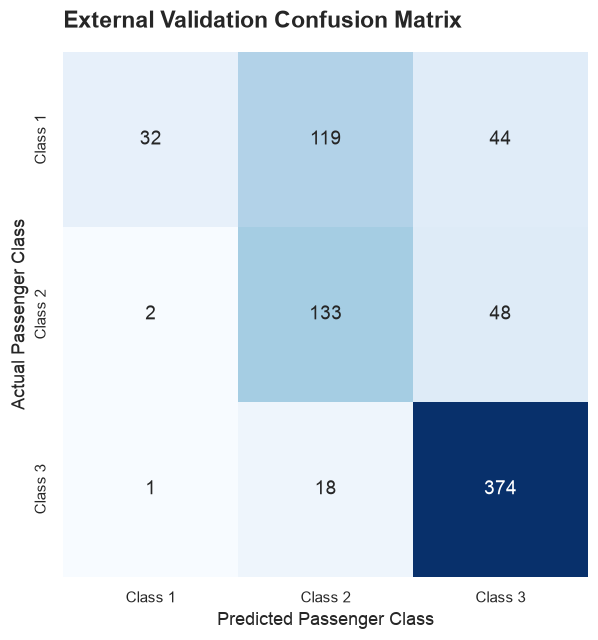

In [27]:
# ==========================================================
# External metrics and confusion matrix
# ==========================================================

external_metrics_path = (
    EXTERNAL_PREDICTIONS_DIR
    / "external_test_metrics.json"
)

if not external_metrics_path.exists():
    raise FileNotFoundError(
        "External metrics were not found at:\n"
        f"{external_metrics_path}"
    )

with external_metrics_path.open("r", encoding="utf-8") as file:
    external_metrics_raw = json.load(file)

print(f"Loaded from: {external_metrics_path}")

external_scalar_metrics = {
    key: value
    for key, value in external_metrics_raw.items()
    if isinstance(value, (int, float))
    and not isinstance(value, bool)
}

external_metrics_table = pd.DataFrame(
    {
        "Metric": [
            key.replace("_", " ").title()
            for key in external_scalar_metrics
        ],
        "Score": list(external_scalar_metrics.values()),
    }
)

display_section_table(
    external_metrics_table,
    caption="Independent External Performance",
    decimals=4,
)

external_confusion_matrix = np.asarray(
    external_metrics_raw.get("confusion_matrix", [])
)

if external_confusion_matrix.shape == (3, 3):
    plt.figure(figsize=(7, 6))

    sns.heatmap(
        external_confusion_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=["Class 1", "Class 2", "Class 3"],
        yticklabels=["Class 1", "Class 2", "Class 3"],
    )

    finish_plot(
        title="External Validation Confusion Matrix",
        xlabel="Predicted Passenger Class",
        ylabel="Actual Passenger Class",
    )
else:
    print(
        "A 3 × 3 external confusion matrix was not found "
        "inside external_test_metrics.json."
    )


## 8.3 External Classification Report

The classification report complements the confusion matrix with precision, recall, and F1 scores for each passenger class. Macro averages give each class equal weight, while weighted averages account for class frequency.


In [28]:
# ==========================================================
# External classification report
# ==========================================================

external_report_path = (
    EXTERNAL_PREDICTIONS_DIR
    / "external_classification_report.csv"
)

if external_report_path.exists():
    external_report = pd.read_csv(external_report_path)

    # Improve the first column name when the CSV contains an
    # unnamed index exported by pandas.
    if external_report.columns[0].startswith("Unnamed"):
        external_report = external_report.rename(
            columns={external_report.columns[0]: "Class"}
        )

    print(f"Loaded from: {external_report_path}")

    display_section_table(
        external_report,
        caption="External Classification Report",
        decimals=4,
    )
else:
    print(
        "External classification report unavailable at:\n"
        f"{external_report_path}"
    )


Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/predictions/external_nonoverlap/external_classification_report.csv


label,precision,recall,f1-score,support
1,0.9143,0.1641,0.2783,195.0000
2,0.4926,0.7268,0.5872,183.0000
3,0.8026,0.9517,0.8708,393.0000
accuracy,0.6991,0.6991,0.6991,0.6991
macro avg,0.7365,0.6142,0.5787,771.0000
weighted avg,0.7573,0.6991,0.6536,771.0000


## 8.4 Internal versus External Performance

The comparison below includes only scalar metrics shared by both JSON artifacts. Structured values such as confusion matrices are deliberately excluded from subtraction and plotting.


Metric,Internal,External,Change
Accuracy,0.8883,0.6991,-0.1892
Balanced Accuracy,0.8600,0.6142,-0.2458
F1 Macro,0.8641,0.5787,-0.2854


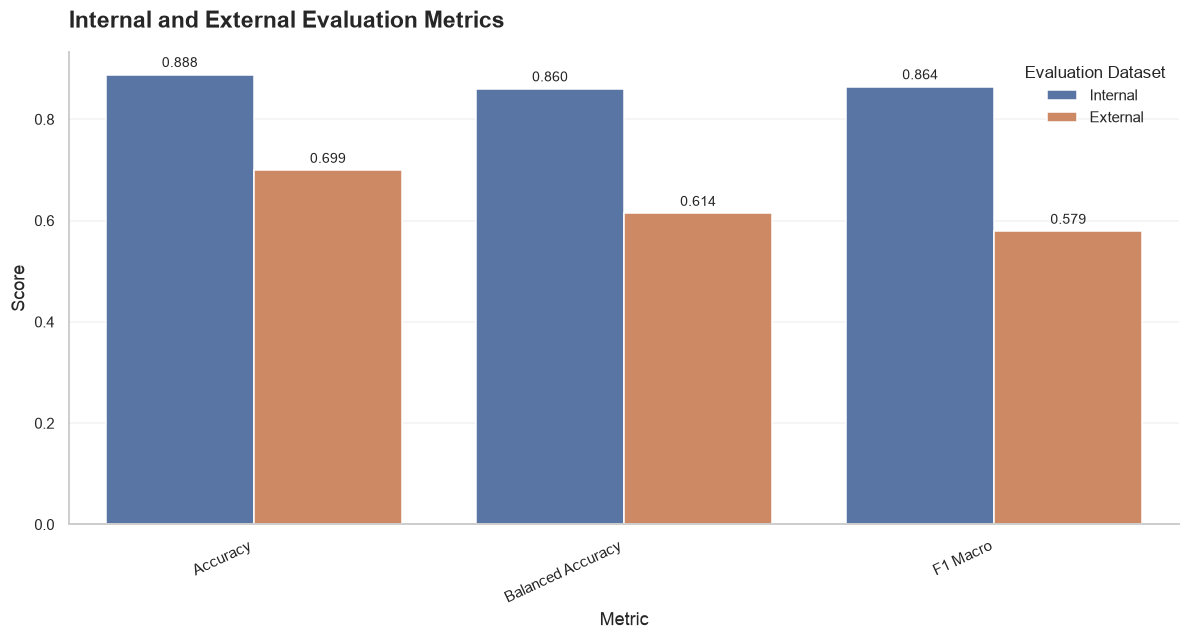

In [29]:
# ==========================================================
# Internal versus external scalar metrics
# ==========================================================

shared_metric_keys = [
    key
    for key in internal_scalar_metrics
    if key in external_scalar_metrics
]

metric_comparison = pd.DataFrame(
    {
        "Metric": [
            key.replace("_", " ").title()
            for key in shared_metric_keys
        ],
        "Internal": [
            internal_scalar_metrics[key]
            for key in shared_metric_keys
        ],
        "External": [
            external_scalar_metrics[key]
            for key in shared_metric_keys
        ],
    }
)

metric_comparison["Change"] = (
    metric_comparison["External"]
    - metric_comparison["Internal"]
)

display_section_table(
    metric_comparison,
    caption="Internal and External Performance Comparison",
    decimals=4,
)

comparison_plot = metric_comparison.melt(
    id_vars="Metric",
    value_vars=["Internal", "External"],
    var_name="Evaluation Dataset",
    value_name="Score",
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparison_plot,
    x="Metric",
    y="Score",
    hue="Evaluation Dataset",
)

add_bar_labels(
    ax,
    decimals=3,
)

finish_plot(
    title="Internal and External Evaluation Metrics",
    xlabel="Metric",
    ylabel="Score",
    legend_title="Evaluation Dataset",
    rotate_x=25,
)


## 8.5 Interpretation of External Validation

A decrease from internal to external performance is evidence of distribution shift, not automatically evidence of model failure. The meaningful questions are:

- whether performance remains substantially above a naive baseline,
- whether all three classes retain usable recall,
- and whether the external confusion pattern remains understandable.

The tables and heatmaps above support those comparisons without making claims that are not directly shown by the saved artifacts.


# 9. Model Interpretation

This section uses saved figures and prediction artifacts produced by the modular training and evaluation pipeline. It does not recompute feature importance inside the notebook.


## 9.1 Saved Feature-Importance Figures



Aggregated feature importance
Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/reports/figures/aggregated_feature_importance.png


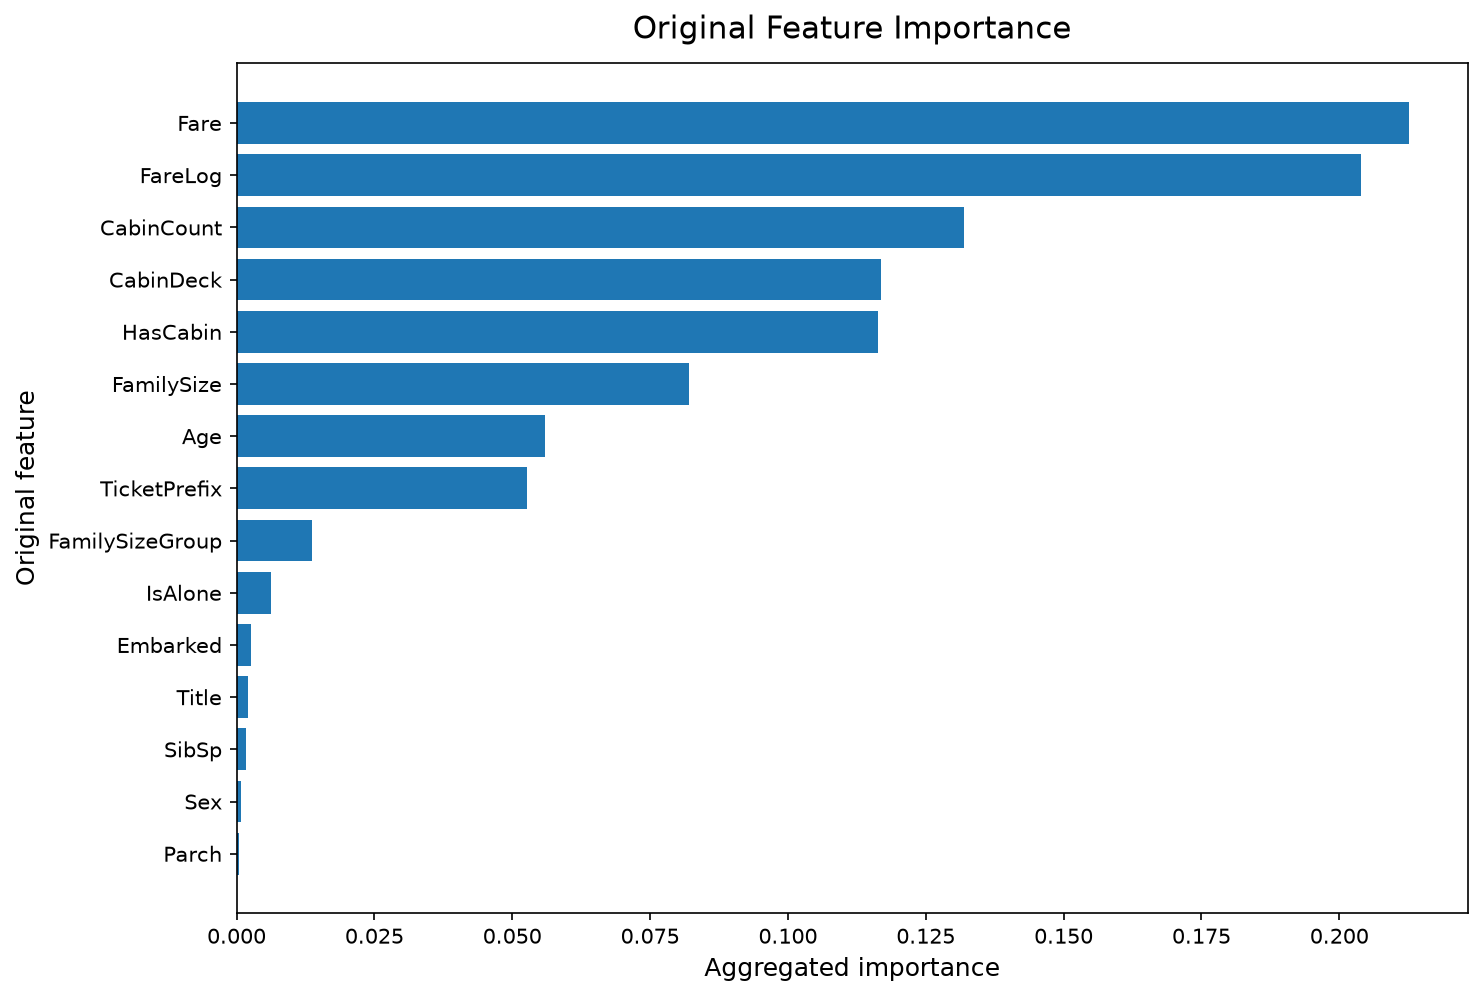


Encoded feature importance
Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/reports/figures/feature_importance.png


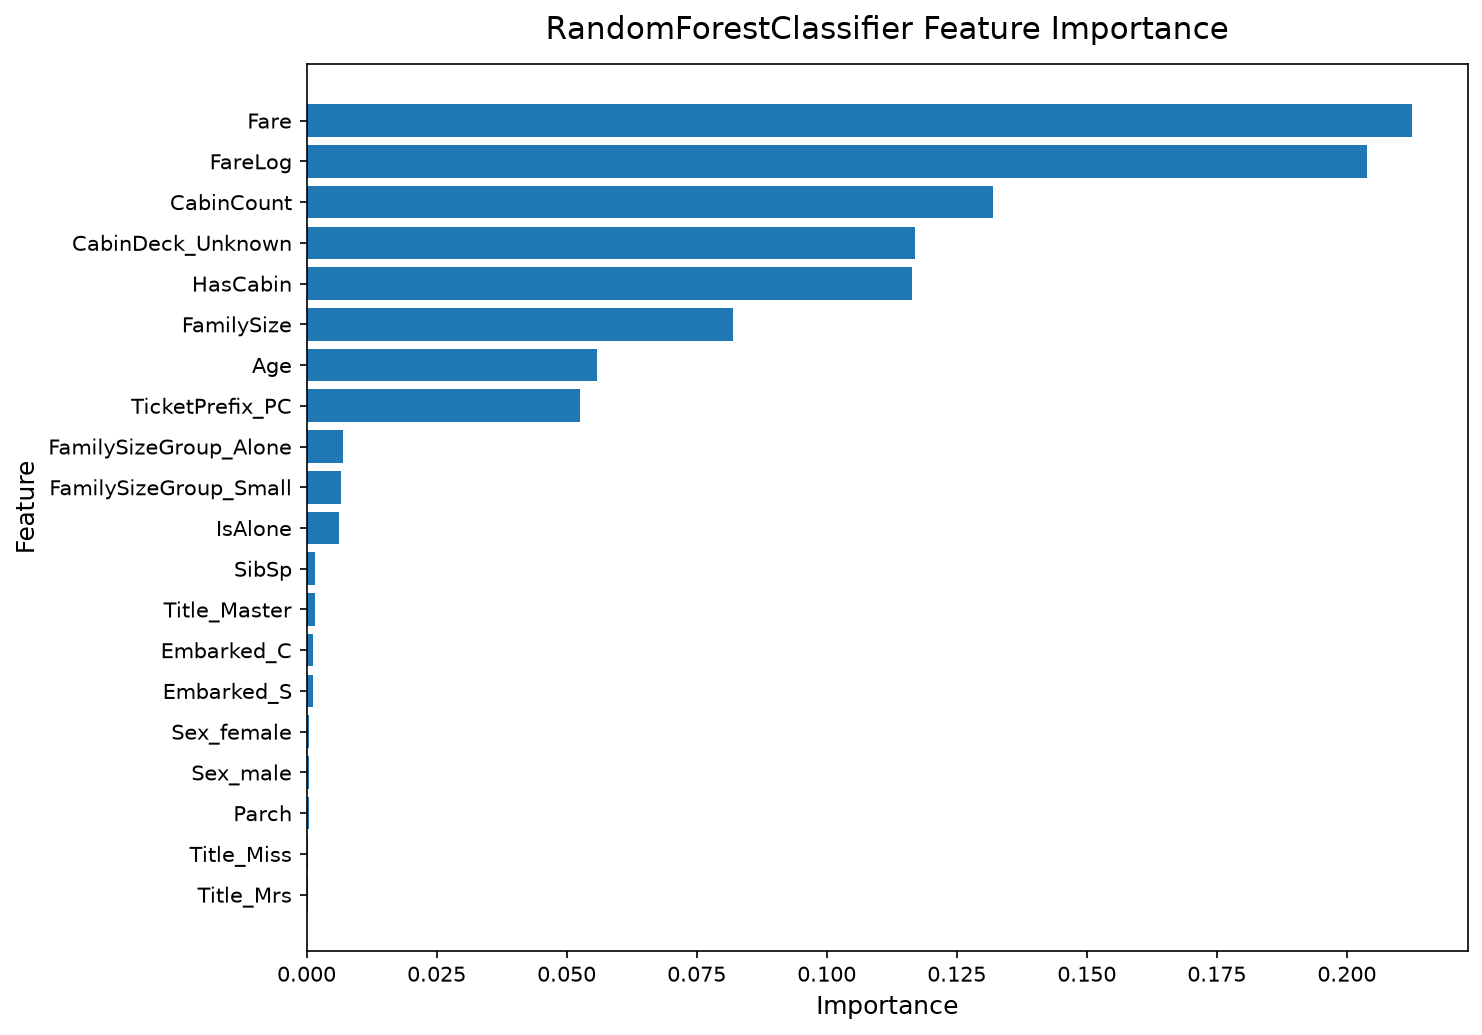


Permutation importance
Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/reports/figures/permutation_importance.png


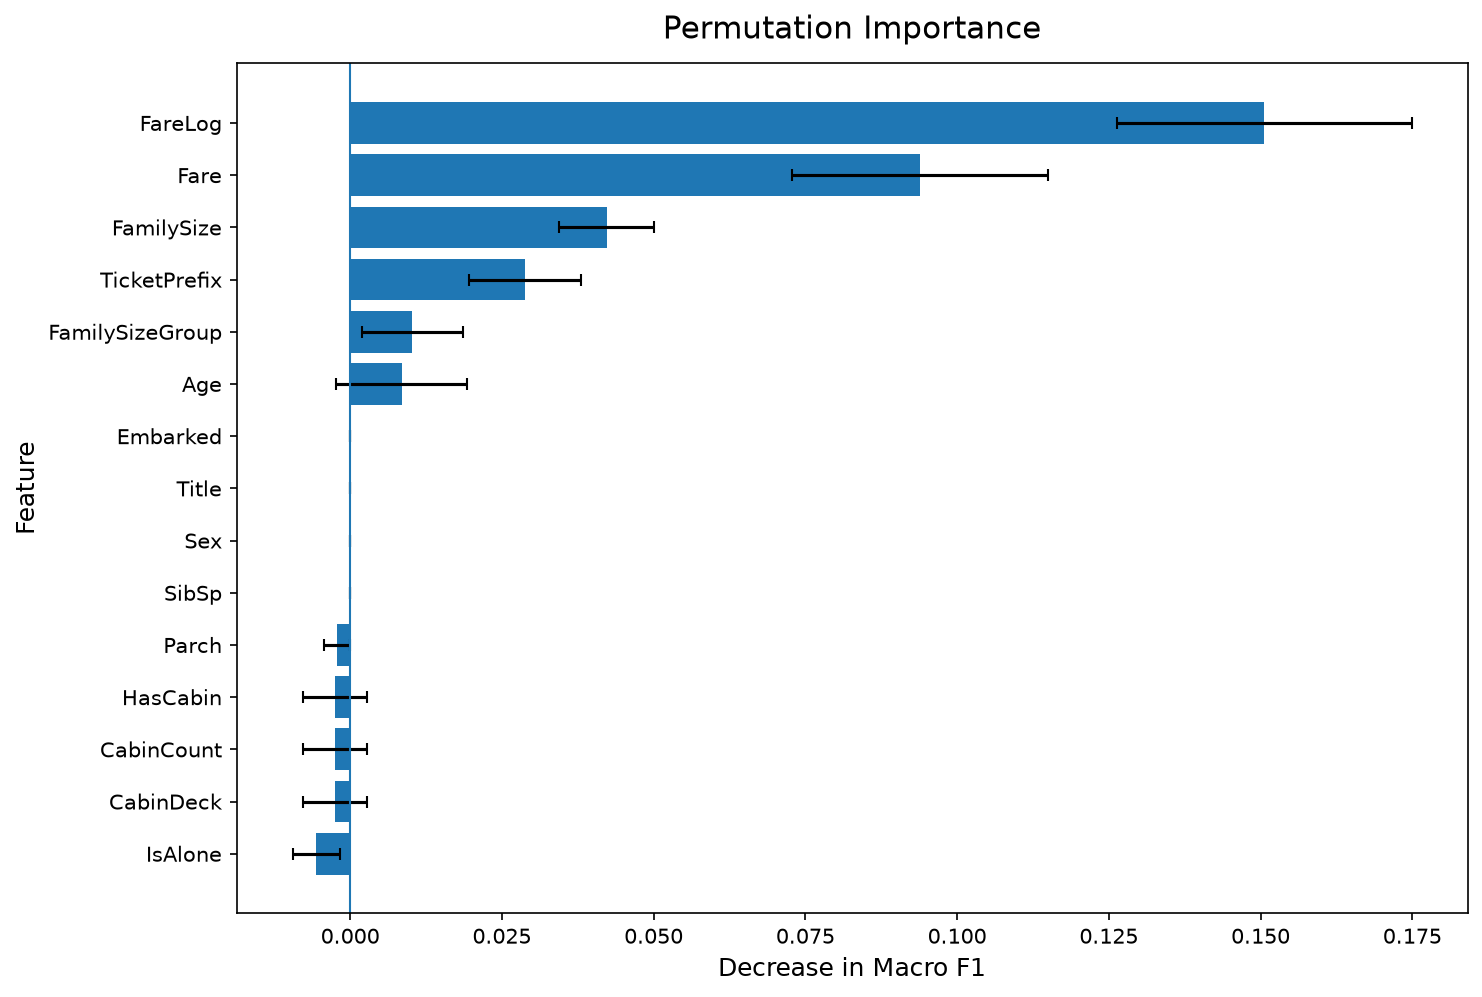

In [30]:
# ==========================================================
# Saved feature-importance figures
# ==========================================================

from IPython.display import Image, display

importance_figures = [
    (
        "Aggregated feature importance",
        FIGURES_DIR / "aggregated_feature_importance.png",
    ),
    (
        "Encoded feature importance",
        FIGURES_DIR / "feature_importance.png",
    ),
    (
        "Permutation importance",
        FIGURES_DIR / "permutation_importance.png",
    ),
]

available_importance_figures = [
    (title, path)
    for title, path in importance_figures
    if path.exists()
]

if not available_importance_figures:
    print(f"No feature-importance figures found in {FIGURES_DIR}")
else:
    for title, path in available_importance_figures:
        print(f"\n{title}")
        print(f"Loaded from: {path}")
        display(Image(filename=str(path), width=900))


### Interpretation

Impurity-based and permutation importance answer related but different questions. Impurity importance describes how strongly features are used across the fitted trees. Permutation importance measures the decline in predictive performance when a feature is disrupted.

Neither measure establishes causality. Their role here is to explain which variables the fitted model relies on for passenger-class prediction.


## 9.2 Prediction Confidence


Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/predictions/external_nonoverlap/test_predictions.csv
Shape: (771, 16)
Columns: ['PassengerId', 'Name', 'Sex', 'Age', 'Fare', 'Embarked', 'Pclass', 'PredictedPclass', 'PredictionCorrect', 'ProbabilityClass1', 'ProbabilityClass2', 'ProbabilityClass3', 'PredictionConfidence', 'SecondHighestProbability', 'ProbabilityMargin', 'LowConfidencePrediction']


Statistic,Value
count,771.0000
mean,0.8902
std,0.1782
min,0.5476
10%,0.5714
25%,0.7500
50%,1.0000
75%,1.0000
90%,1.0000
max,1.0000


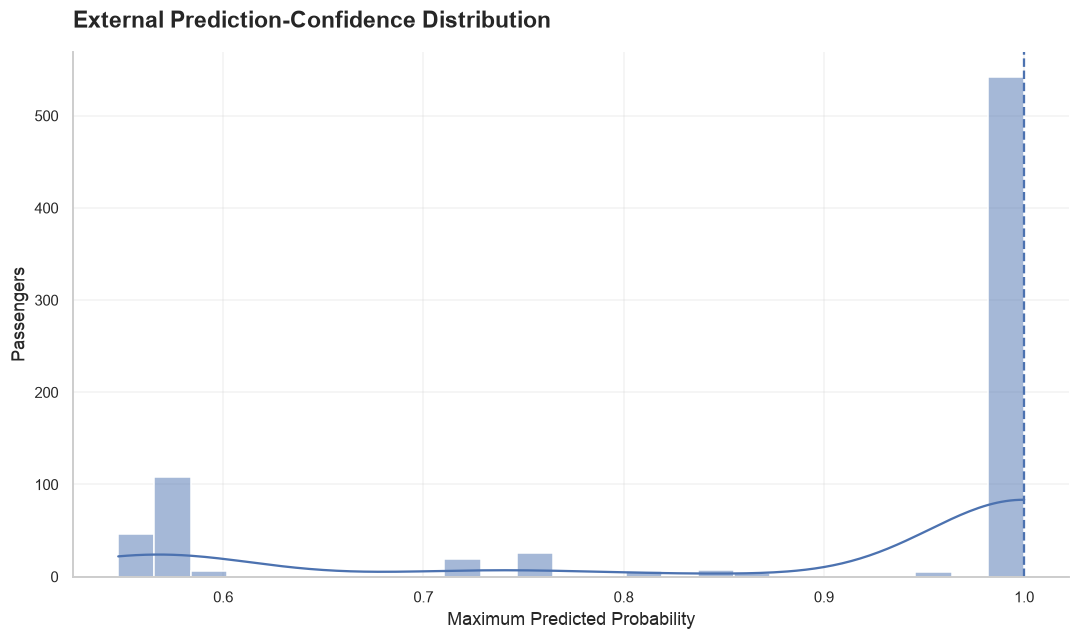

PassengerId,Name,Sex,Age,Fare,Embarked,Pclass,PredictedPclass,PredictionCorrect,ProbabilityClass1,ProbabilityClass2,ProbabilityClass3,PredictionConfidence,SecondHighestProbability,ProbabilityMargin,LowConfidencePrediction
2.0000,"Abbott, Mr. Eugene Joseph",male,13.0000,20.0500,S,3.0000,3.0000,True,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
801.0000,"Mellinger, Miss. Violet Madeline",female,13.0000,19.1000,S,2.0000,3.0000,False,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
"1,033.0000","Rosblom, Mrs. Helena Wilhelmina",female,41.0000,20.0403,S,3.0000,3.0000,True,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
"1,080.0000","Sandström, Mrs. Agnes Charlotta",female,24.0000,16.1400,S,3.0000,3.0000,True,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
802.0000,"Mellinger, Mrs. Elizabeth Anne",female,42.0000,19.1000,S,2.0000,3.0000,False,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
492.0000,"Hämäläinen, Mrs. Anna",female,23.0000,14.1000,S,2.0000,3.0000,False,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
281.0000,"Cribb, Miss. Laura Mae",female,16.0000,16.0200,S,3.0000,3.0000,True,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
277.0000,"Coutts, Mrs. Winnie",female,36.0000,15.1800,S,3.0000,3.0000,True,0.0000,0.4524,0.5476,0.5476,0.4524,0.0952,True
120.0000,"Bird, Miss. Ellen",female,31.0000,221.1507,S,1.0000,3.0000,False,0.2222,0.2222,0.5556,0.5556,0.2222,0.3333,True
"1,102.0000","Shutes, Miss. Elizabeth Weed",female,40.0000,153.0903,S,1.0000,3.0000,False,0.2222,0.2222,0.5556,0.5556,0.2222,0.3333,True


In [31]:
# ==========================================================
# External predictions and confidence
# ==========================================================

external_predictions_path = (
    EXTERNAL_PREDICTIONS_DIR
    / "test_predictions.csv"
)

if not external_predictions_path.exists():
    print(
        "External predictions were not found at:\n"
        f"{external_predictions_path}"
    )
else:
    external_predictions = pd.read_csv(
        external_predictions_path
    )

    print(f"Loaded from: {external_predictions_path}")
    print(f"Shape: {external_predictions.shape}")
    print(f"Columns: {list(external_predictions.columns)}")

    probability_columns = [
        column
        for column in external_predictions.columns
        if (
            column.lower().startswith("prob")
            or "probability" in column.lower()
            or "proba" in column.lower()
        )
    ]

    existing_confidence_column = next(
        (
            column
            for column in external_predictions.columns
            if column.lower() in {
                "confidence",
                "prediction_confidence",
                "max_probability",
            }
        ),
        None,
    )

    if probability_columns:
        probability_frame = external_predictions[
            probability_columns
        ].apply(pd.to_numeric, errors="coerce")

        external_predictions["PredictionConfidence"] = (
            probability_frame.max(axis=1)
        )

    elif existing_confidence_column is not None:
        external_predictions["PredictionConfidence"] = (
            pd.to_numeric(
                external_predictions[
                    existing_confidence_column
                ],
                errors="coerce",
            )
        )

    else:
        external_predictions["PredictionConfidence"] = np.nan

    confidence = external_predictions[
        "PredictionConfidence"
    ].dropna()

    if confidence.empty:
        print(
            "The prediction CSV does not contain class "
            "probabilities or a confidence column."
        )
        display(external_predictions.head())
    else:
        confidence_summary = (
            confidence
            .describe(
                percentiles=[
                    0.10,
                    0.25,
                    0.50,
                    0.75,
                    0.90,
                ]
            )
            .rename_axis("Statistic")
            .reset_index(name="Value")
        )

        display_section_table(
            confidence_summary,
            caption="External Prediction Confidence",
            decimals=4,
        )

        plt.figure(figsize=(10, 6))

        sns.histplot(
            confidence,
            bins=25,
            kde=True,
        )

        plt.axvline(
            confidence.median(),
            linestyle="--",
            linewidth=1.5,
            label="Median",
        )

        finish_plot(
            title="External Prediction-Confidence Distribution",
            xlabel="Maximum Predicted Probability",
            ylabel="Passengers",
            legend_title=None,
        )

        low_confidence_predictions = (
            external_predictions
            .sort_values("PredictionConfidence")
            .head(10)
        )

        display_section_table(
            low_confidence_predictions,
            caption="Lowest-Confidence External Predictions",
            decimals=4,
        )


## 9.3 Prediction Summary


In [32]:
# ==========================================================
# Saved external prediction summary
# ==========================================================

prediction_summary_path = (
    EXTERNAL_PREDICTIONS_DIR
    / "test_prediction_summary.json"
)

if prediction_summary_path.exists():
    with prediction_summary_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        prediction_summary_raw = json.load(file)

    prediction_summary_table = pd.DataFrame(
        {
            "Statistic": [
                key.replace("_", " ").title()
                for key in prediction_summary_raw
            ],
            "Value": list(prediction_summary_raw.values()),
        }
    )

    print(f"Loaded from: {prediction_summary_path}")

    display(prediction_summary_table)
else:
    print(
        "Prediction summary unavailable at:\n"
        f"{prediction_summary_path}"
    )


Loaded from: /Users/pontusbjorkell/Desktop/Titanic-Passenger-Class-Prediction/artifacts/predictions/external_nonoverlap/test_prediction_summary.json


,Statistic,Value
0,Created At Utc,2026-07-21T00:58:48.798644+00:00
1,External Evaluation Performed,True
2,External Metrics,"{'accuracy': 0.6990920881971465, 'balanced_accuracy': 0.6141774881356911, 'c..."
3,Input Path,data/external/titanic_external_nonoverlap.csv
4,Low Confidence Count,154
5,Low Confidence Percentage,19.974
6,Low Confidence Threshold,0.600
7,Maximum Prediction Confidence,1.000
8,Mean Prediction Confidence,0.890
9,Median Prediction Confidence,1.000


## 9.4 Error Analysis

The internal and external confusion matrices should be interpreted directly rather than described in advance. Large off-diagonal cells identify the class pairs the model finds most difficult to separate.

Likewise, the lowest-confidence predictions identify passengers whose characteristics place them near a learned decision boundary. These cases are more informative for model diagnosis than a general claim that one particular class pair must always dominate the errors.


# 10. Discussion

This project combines exploratory analysis with a modular machine-learning workflow and saved evaluation artifacts.

Its strongest elements are:

- a clearly defined multiclass prediction target,
- reusable preprocessing and feature engineering,
- automated model training and testing,
- a separate external validation dataset,
- artifact-driven evaluation,
- and a Streamlit application built on the same project structure.

The external evaluation is especially valuable because it exposes the model to a different data source rather than only a random split of the original data.


## 10.1 Limitations

Several limitations remain:

- The available Titanic datasets are small by modern machine-learning standards.
- Passenger-class boundaries overlap in variables such as fare, age, and family structure.
- Missing age and cabin information require preprocessing assumptions.
- External datasets may use different conventions or historical reconstructions.
- Feature importance measures predictive reliance, not causal influence.
- Confidence values should not be described as calibrated probabilities unless calibration has been tested explicitly.


## 10.2 Possible Extensions

Useful extensions include:

- probability-calibration analysis,
- SHAP explanations,
- repeated cross-validation,
- additional external-data audits,
- explicit monitoring of distribution shift,
- and integration of the notebook figures into the Streamlit reporting pages.

These are future enhancements rather than claims about the present implementation.


# 11. Conclusion

The project demonstrates a complete supervised-learning workflow for predicting Titanic passenger class.

The notebook now separates four distinct tasks:

1. exploratory analysis of the training data,
2. explanation of engineered features and preprocessing,
3. evaluation on the internal hold-out set,
4. independent validation using saved external artifacts.

All file paths are resolved from the repository root. Scalar metrics, classification reports, confusion matrices, saved figures, and prediction outputs are presented according to their actual data structure rather than forced into a single table format.


## Reproducibility

The notebook reads outputs created by the repository's modular scripts. To reproduce the complete report:

1. prepare the raw and external data,
2. train and evaluate the model,
3. generate external predictions,
4. then restart the notebook kernel and run all cells.

The notebook does not silently substitute missing artifacts. Missing files are reported with their expected absolute path.


# References

- Breiman, L. (2001). *Random Forests*. *Machine Learning*, 45, 5–32.
- pandas documentation
- NumPy documentation
- scikit-learn documentation
- Matplotlib documentation
- Seaborn documentation
